# CREF cross-group summary analysis

Aggregates per-image results from the GMM and Radon pipelines by **lab**, **period** (T1–T3), and **position group** (A/B/C).

**Prerequisites** (run once with all filters `None`):
- [`gmm_nn_unsup.ipynb`](gmm_nn_unsup.ipynb) or `python gmm_nn_unsup_4.py`
- [`radon_track_nn.ipynb`](radon_track_nn.ipynb)

Reads `cref/outputs/gmm_per_image_cref.csv` and `cref/outputs/radon_per_image_cref.csv`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from gmm_nn_unsup_4 import (
    GMM_COUNT_COLS,
    RADON_COUNT_COLS,
    add_within_tile_centered,
    build_cref_summaries,
    enrich_with_cref_metadata,
    pivot_lab_period,
    pivot_lab_period_dispersion,
    plot_deviation_strip,
    plot_lab_period_position_heatmaps,
    plot_lab_period_scalar_heatmaps,
    plot_tile_dispersion_bars,
    save_cref_summaries,
    summarize_cref_inventory,
    tile_dispersion_table,
)

sns.set_theme(style="white", context="talk", font_scale=0.85)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

CREF_DIR = Path.cwd() if (Path.cwd() / "gmm_nn_unsup_4.py").exists() else Path.cwd() / "cref"
OUTPUT_DIR = CREF_DIR / "outputs"
DATA_DIR = CREF_DIR.parent / "data_cref" / "data"
REQUIRE_FULL_DATASET = True
EXPECTED_N = summarize_cref_inventory(DATA_DIR)["total_files"]

GMM_PER_IMAGE = OUTPUT_DIR / "gmm_per_image_cref.csv"
RADON_PER_IMAGE = OUTPUT_DIR / "radon_per_image_cref.csv"

print(f"CREF output dir: {OUTPUT_DIR}")
print(f"Expected images: {EXPECTED_N}")

from IPython.display import Markdown, display

_figure_n = 0


def fig_caption(text: str, filename: str | None = None) -> None:
    """Show a numbered caption under the most recent figure."""
    global _figure_n
    _figure_n += 1
    file_note = f" Saved as `{filename}`." if filename else ""
    display(Markdown(f"**Figure {_figure_n}.** {text}{file_note}"))


CREF output dir: /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs
Expected images: 225


In [2]:
def load_per_image(path: Path, count_cols: list[str]) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run the corresponding pipeline notebook first."
        )
    df = pd.read_csv(path)
    if "lab" not in df.columns:
        df = enrich_with_cref_metadata(df)
    n = len(df)
    if REQUIRE_FULL_DATASET and n != EXPECTED_N:
        print(f"Warning: {path.name} has {n} rows (expected {EXPECTED_N}).")
    present = [c for c in count_cols if c in df.columns]
    print(f"Loaded {path.name}: {n} images, count cols: {present}")
    return df

gmm_df = load_per_image(GMM_PER_IMAGE, GMM_COUNT_COLS)
radon_df = load_per_image(RADON_PER_IMAGE, RADON_COUNT_COLS)

Loaded gmm_per_image_cref.csv: 225 images, count cols: ['imagej_count', 'gmm_count', 'gmm_ws_count', 'gmm_ws_clean_count']
Loaded radon_per_image_cref.csv: 225 images, count cols: ['imagej_count', 'macro_repro', 'improved', 'nn_clean_count']


In [3]:
gmm_summaries = build_cref_summaries(gmm_df, GMM_COUNT_COLS)
radon_summaries = build_cref_summaries(radon_df, RADON_COUNT_COLS)
save_cref_summaries(gmm_summaries, OUTPUT_DIR, prefix="gmm")
save_cref_summaries(radon_summaries, OUTPUT_DIR, prefix="radon")
print(f"Saved summaries to {OUTPUT_DIR / 'summaries'}")

Saved summaries to /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries


## Period dependence (each lab × period, and period totals)

In [4]:
print("=== GMM: by lab × period ===")
display(gmm_summaries["by_lab_period"])
print("=== GMM: period totals ===")
display(gmm_summaries["by_period"])
print("=== Radon: by lab × period ===")
display(radon_summaries["by_lab_period"])
print("=== Radon: period totals ===")
display(radon_summaries["by_period"])

=== GMM: by lab × period ===


,lab,period,n_images,sum_imagej_count,mean_imagej_count,sum_gmm_count,mean_gmm_count,sum_gmm_ws_count,mean_gmm_ws_count,sum_gmm_ws_clean_count,mean_gmm_ws_clean_count
0,P2-DOT,T1,15,13570,904.666667,14995,999.666667,15545,1036.333333,10918,727.866667
1,P2-DOT,T2,15,20120,1341.333333,24471,1631.400000,28995,1933.000000,24289,1619.266667
2,P2-DOT,T3,15,10539,702.600000,12087,805.800000,13922,928.133333,10558,703.866667
3,PS-LAB,T1,15,11278,751.866667,13103,873.533333,13763,917.533333,11357,757.133333
4,PS-LAB,T2,15,16166,1077.733333,19704,1313.600000,22336,1489.066667,19486,1299.066667
5,PS-LAB,T3,15,8310,554.000000,9707,647.133333,11930,795.333333,9117,607.800000
6,PS-RIS,T1,15,4871,324.733333,5540,369.333333,5843,389.533333,4738,315.866667
7,PS-RIS,T2,15,8649,576.600000,11033,735.533333,15047,1003.133333,13747,916.466667
8,PS-RIS,T3,15,6116,407.733333,7279,485.266667,9122,608.133333,7448,496.533333
9,PT-MUS,T1,15,8378,558.533333,9290,619.333333,9933,662.200000,6974,464.933333


=== GMM: period totals ===


,period,n_images,sum_imagej_count,mean_imagej_count,sum_gmm_count,mean_gmm_count,sum_gmm_ws_count,mean_gmm_ws_count,sum_gmm_ws_clean_count,mean_gmm_ws_clean_count
0,T1,75,43706,582.746667,49489,659.853333,52233,696.440000,40138,535.173333
1,T2,75,66389,885.186667,82229,1096.386667,100226,1336.346667,87849,1171.320000
2,T3,75,44645,595.266667,51869,691.586667,62378,831.706667,48076,641.013333


=== Radon: by lab × period ===


,lab,period,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,P2-DOT,T1,15,13570,904.666667,15144,1009.600000,19368,1291.200000,40,2.666667
1,P2-DOT,T2,15,20120,1341.333333,22217,1481.133333,36243,2416.200000,206,13.733333
2,P2-DOT,T3,15,10539,702.600000,11749,783.266667,19231,1282.066667,148,9.866667
3,PS-LAB,T1,15,11278,751.866667,12603,840.200000,14988,999.200000,12,0.800000
4,PS-LAB,T2,15,16166,1077.733333,17689,1179.266667,29654,1976.933333,254,16.933333
5,PS-LAB,T3,15,8310,554.000000,9256,617.066667,15466,1031.066667,58,3.866667
6,PS-RIS,T1,15,4871,324.733333,5363,357.533333,6446,429.733333,13,0.866667
7,PS-RIS,T2,15,8649,576.600000,9334,622.266667,21944,1462.933333,180,12.000000
8,PS-RIS,T3,15,6116,407.733333,6779,451.933333,12084,805.600000,43,2.866667
9,PT-MUS,T1,15,8378,558.533333,9258,617.200000,11073,738.200000,6,0.400000


=== Radon: period totals ===


,period,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,T1,75,43706,582.746667,48541,647.213333,61049,813.986667,115,1.533333
1,T2,75,66389,885.186667,72703,969.373333,132544,1767.253333,998,13.306667
2,T3,75,44645,595.266667,49727,663.026667,82403,1098.706667,397,5.293333


## Position dependence (A/B/C per lab×period, per lab, per period)

In [5]:
for label, summaries in [("GMM", gmm_summaries), ("Radon", radon_summaries)]:
    print(f"=== {label}: lab × period × position ===")
    display(summaries["by_lab_period_position"])
    print(f"=== {label}: lab × position (periods pooled) ===")
    display(summaries["by_lab_position"])
    print(f"=== {label}: period × position (labs pooled) ===")
    display(summaries["by_period_position"])
    print(f"=== {label}: position totals A/B/C ===")
    display(summaries["by_position_group"])

=== GMM: lab × period × position ===


,lab,period,position_group,n_images,sum_imagej_count,mean_imagej_count,sum_gmm_count,mean_gmm_count,sum_gmm_ws_count,mean_gmm_ws_count,sum_gmm_ws_clean_count,mean_gmm_ws_clean_count
0,P2-DOT,T1,A,5,5012,1002.4,5534,1106.8,5710,1142.0,3962,792.4
1,P2-DOT,T1,B,5,4206,841.2,4609,921.8,4811,962.2,3379,675.8
2,P2-DOT,T1,C,5,4352,870.4,4852,970.4,5024,1004.8,3577,715.4
3,P2-DOT,T2,A,5,7272,1454.4,8819,1763.8,10531,2106.2,8827,1765.4
4,P2-DOT,T2,B,5,6266,1253.2,7509,1501.8,8703,1740.6,7228,1445.6
5,P2-DOT,T2,C,5,6582,1316.4,8143,1628.6,9761,1952.2,8234,1646.8
6,P2-DOT,T3,A,5,3460,692.0,3953,790.6,4878,975.6,3691,738.2
7,P2-DOT,T3,B,5,3065,613.0,3443,688.6,3855,771.0,2874,574.8
8,P2-DOT,T3,C,5,4014,802.8,4691,938.2,5189,1037.8,3993,798.6
9,PS-LAB,T1,A,5,3828,765.6,4461,892.2,4764,952.8,3898,779.6


=== GMM: lab × position (periods pooled) ===


,lab,position_group,n_images,sum_imagej_count,mean_imagej_count,sum_gmm_count,mean_gmm_count,sum_gmm_ws_count,mean_gmm_ws_count,sum_gmm_ws_clean_count,mean_gmm_ws_clean_count
0,P2-DOT,A,15,15744,1049.600000,18306,1220.400000,21119,1407.933333,16480,1098.666667
1,P2-DOT,B,15,13537,902.466667,15561,1037.400000,17369,1157.933333,13481,898.733333
2,P2-DOT,C,15,14948,996.533333,17686,1179.066667,19974,1331.600000,15804,1053.600000
3,PS-LAB,A,15,12127,808.466667,14244,949.600000,15723,1048.200000,13039,869.266667
4,PS-LAB,B,15,11773,784.866667,14026,935.066667,16012,1067.466667,13343,889.533333
5,PS-LAB,C,15,11854,790.266667,14244,949.600000,16294,1086.266667,13578,905.200000
6,PS-RIS,A,15,7135,475.666667,8557,570.466667,10266,684.400000,8734,582.266667
7,PS-RIS,B,15,6020,401.333333,7264,484.266667,8856,590.400000,7591,506.066667
8,PS-RIS,C,15,6481,432.066667,8031,535.400000,10890,726.000000,9608,640.533333
9,PT-MUS,A,15,13415,894.333333,15818,1054.533333,18014,1200.933333,14315,954.333333


=== GMM: period × position (labs pooled) ===


...

,lab,position_group,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,P2-DOT,A,15,15744,1049.600000,17465,1164.333333,26470,1764.666667,145,9.666667
1,P2-DOT,B,15,13537,902.466667,15054,1003.600000,22940,1529.333333,138,9.200000
2,P2-DOT,C,15,14948,996.533333,16591,1106.066667,25432,1695.466667,111,7.400000
3,PS-LAB,A,15,12127,808.466667,13385,892.333333,21097,1406.466667,174,11.600000
4,PS-LAB,B,15,11773,784.866667,13057,870.466667,19788,1319.200000,78,5.200000
5,PS-LAB,C,15,11854,790.266667,13106,873.733333,19223,1281.533333,72,4.800000
6,PS-RIS,A,15,7135,475.666667,7778,518.533333,12288,819.200000,53,3.533333
7,PS-RIS,B,15,6020,401.333333,6583,438.866667,10939,729.266667,61,4.066667
8,PS-RIS,C,15,6481,432.066667,7115,474.333333,17247,1149.800000,122,8.133333
9,PT-MUS,A,15,13415,894.333333,14827,988.466667,21566,1437.733333,57,3.800000


=== Radon: period × position (labs pooled) ===


,period,position_group,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,T1,A,25,15537,621.48,17263,690.52,22428,897.12,83,3.32
1,T1,B,25,14114,564.56,15680,627.20,19075,763.00,9,0.36
2,T1,C,25,14055,562.20,15598,623.92,19546,781.84,23,0.92
3,T2,A,25,23578,943.12,25803,1032.12,46452,1858.08,432,17.28
4,T2,B,25,20987,839.48,22949,917.96,39310,1572.40,213,8.52
5,T2,C,25,21824,872.96,23951,958.04,46782,1871.28,353,14.12
6,T3,A,25,15915,636.60,17669,706.76,27414,1096.56,98,3.92
7,T3,B,25,13980,559.20,15663,626.52,27129,1085.16,138,5.52
8,T3,C,25,14750,590.00,16395,655.80,27860,1114.40,161,6.44


=== Radon: position totals A/B/C ===


,position_group,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,A,75,55030,733.733333,60735,809.800000,96294,1283.920000,613,8.173333
1,B,75,49081,654.413333,54292,723.893333,85514,1140.186667,360,4.800000
2,C,75,50629,675.053333,55944,745.920000,94188,1255.840000,537,7.160000


## Grand totals (all CREF files)

In [6]:
print("GMM grand total:")
display(gmm_summaries["grand_total"])
print("Radon grand total:")
display(radon_summaries["grand_total"])

GMM grand total:


,n_images,sum_imagej_count,mean_imagej_count,sum_gmm_count,mean_gmm_count,sum_gmm_ws_count,mean_gmm_ws_count,sum_gmm_ws_clean_count,mean_gmm_ws_clean_count
0,225,154740,687.733333,183587,815.942222,214837,954.831111,176063,782.502222


Radon grand total:


,n_images,sum_imagej_count,mean_imagej_count,sum_macro_repro,mean_macro_repro,sum_improved,mean_improved,sum_nn_clean_count,mean_nn_clean_count
0,225,154740,687.733333,170971,759.871111,275996,1226.648889,1510,6.711111


## Heatmaps (lab × period)

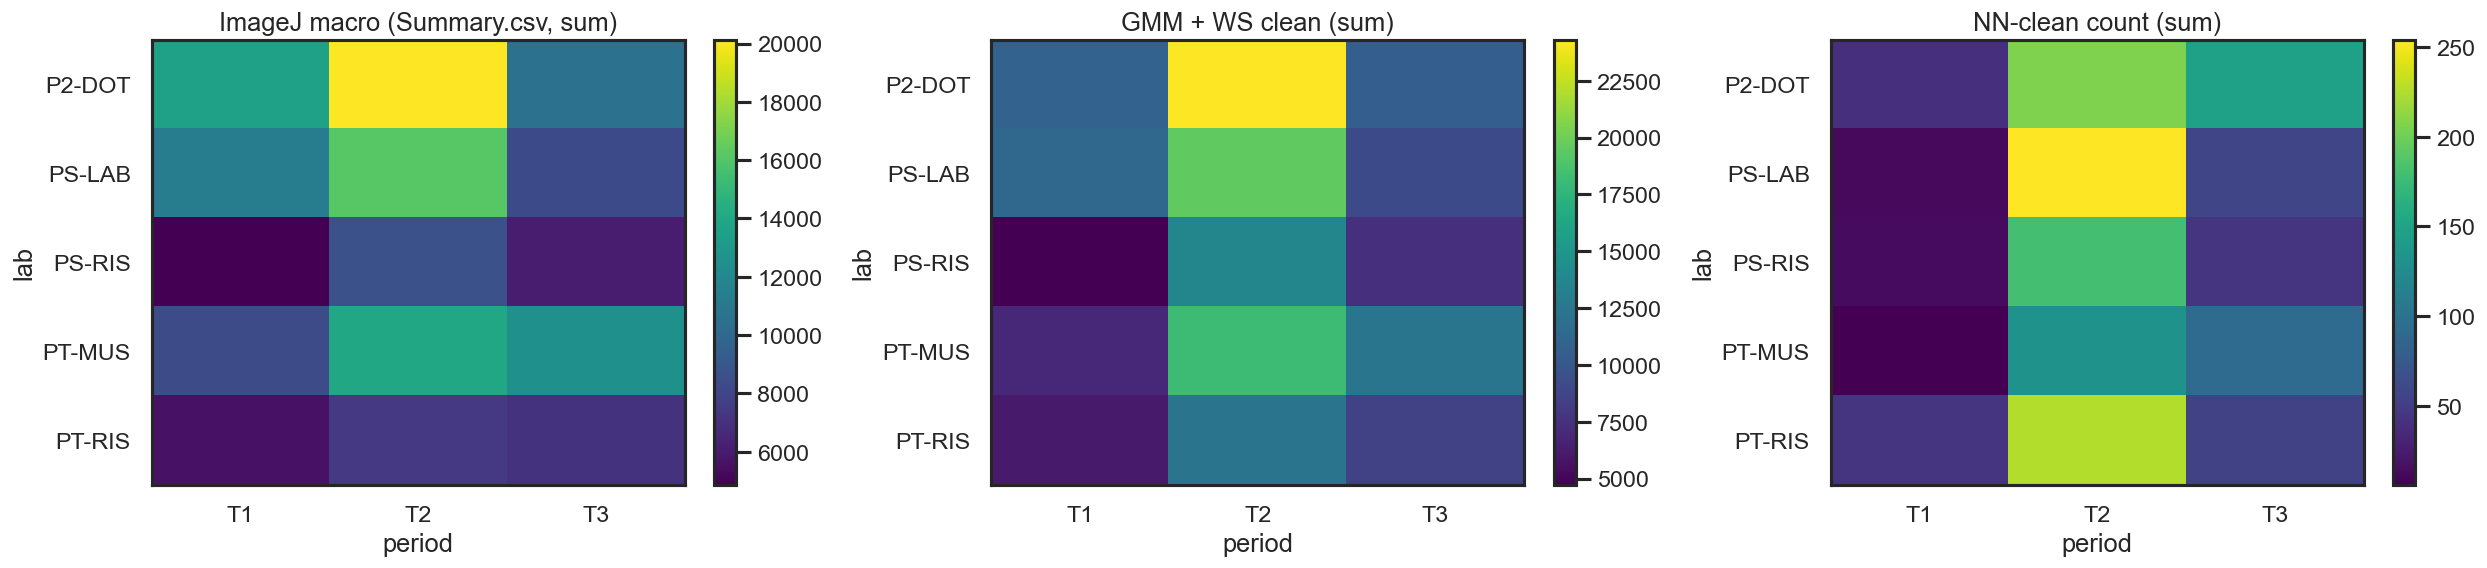

**Figure 1.** Coarse lab × period heatmaps: total counts summed over all 15 detector positions per tile. Saved as `summaries/heatmap_lab_period.png`.

In [7]:
# Heatmaps (lab × period)
_heatmap_panels = [
    (gmm_df, "imagej_count", "ImageJ macro (Summary.csv, sum)"),
    (gmm_df, "gmm_ws_clean_count", "GMM + WS clean (sum)"),
    (radon_df, "nn_clean_count", "NN-clean count (sum)"),
]
fig, axes = plt.subplots(1, len(_heatmap_panels), figsize=(7 * len(_heatmap_panels), 5))
if len(_heatmap_panels) == 1:
    axes = [axes]

for ax, (df, value_col, title) in zip(axes, _heatmap_panels):
    pivot = pivot_lab_period(df, value_col)
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)), labels=pivot.columns)
    ax.set_yticks(range(len(pivot.index)), labels=pivot.index)
    ax.set_title(title)
    ax.set_xlabel("period")
    ax.set_ylabel("lab")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "summaries" / "heatmap_lab_period.png", dpi=120, bbox_inches="tight")
plt.show()
fig_caption(
    "Coarse lab × period heatmaps: total counts summed over all 15 detector positions per tile.",
    "summaries/heatmap_lab_period.png",
)


## Detailed heatmaps (lab × period, 3×5 position per tile)

Each outer tile is one `(lab, period)` pair. Inside the tile: rows **A / B / C**, columns **slots 1–5** (`A1`…`C5`), one detector position per image.

Shared detail scale: vmin=0, vmax=1966


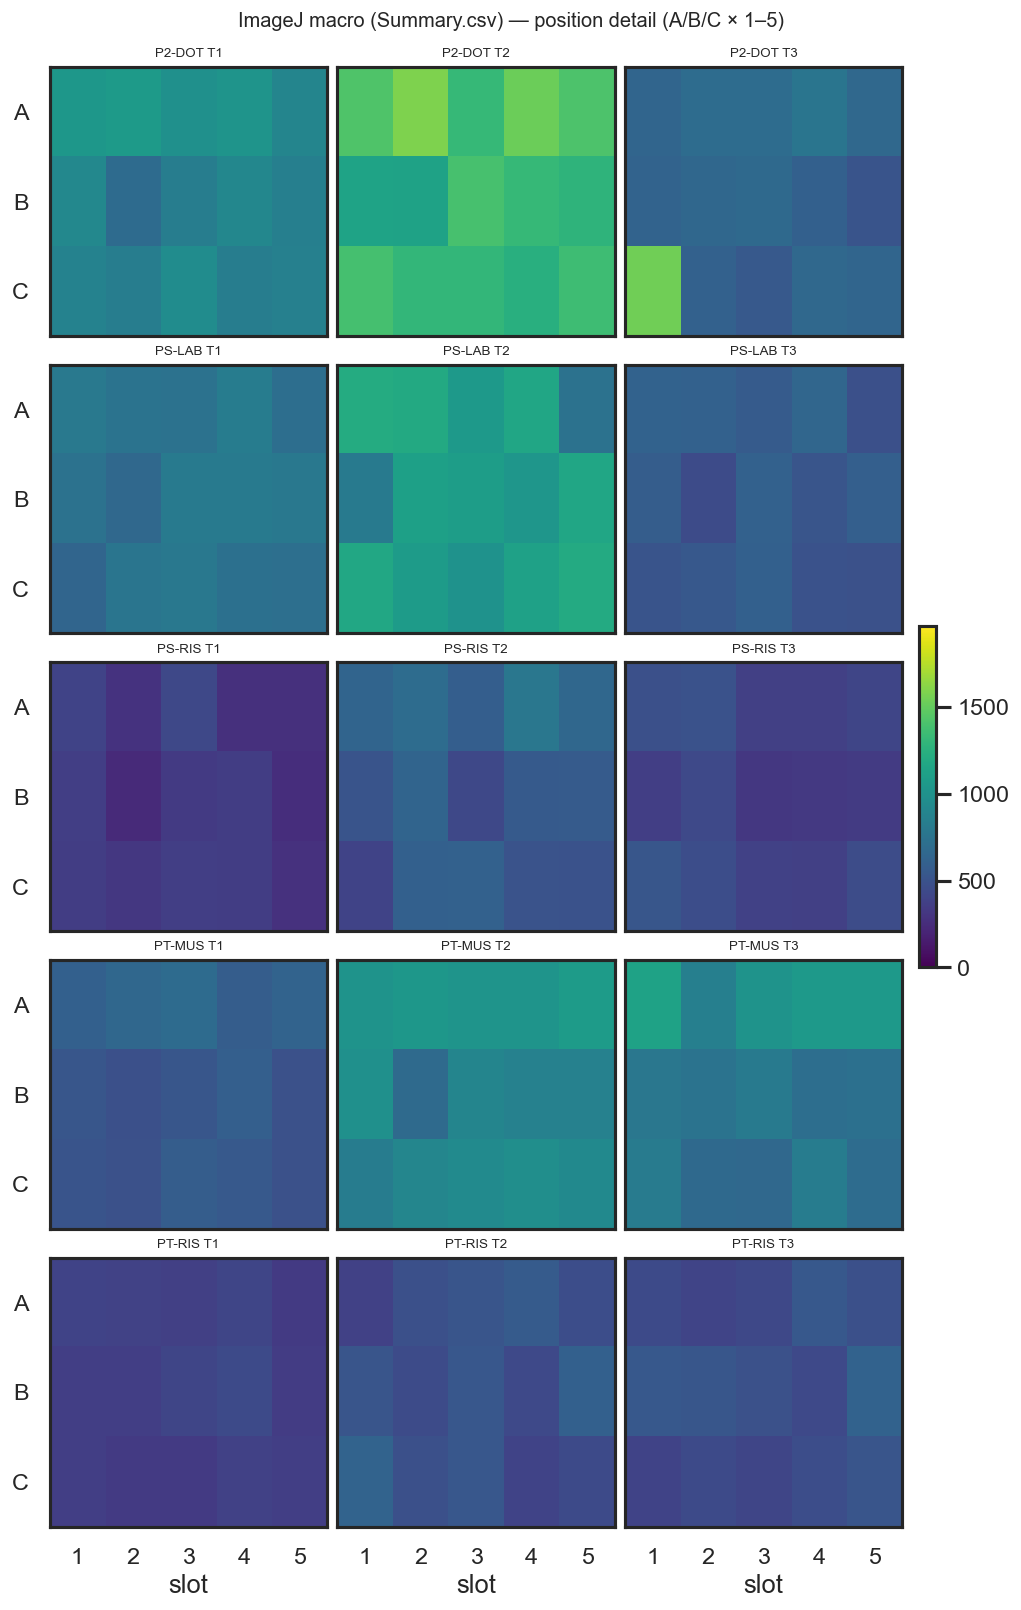

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_detail_imagej_count.png


**Figure 2.** Position mosaic for ImageJ macro (Summary.csv): each outer tile is one lab×period; inner grid is A/B/C × slots 1–5 (shared color scale). Saved as `summaries/heatmap_detail_imagej_count.png`.

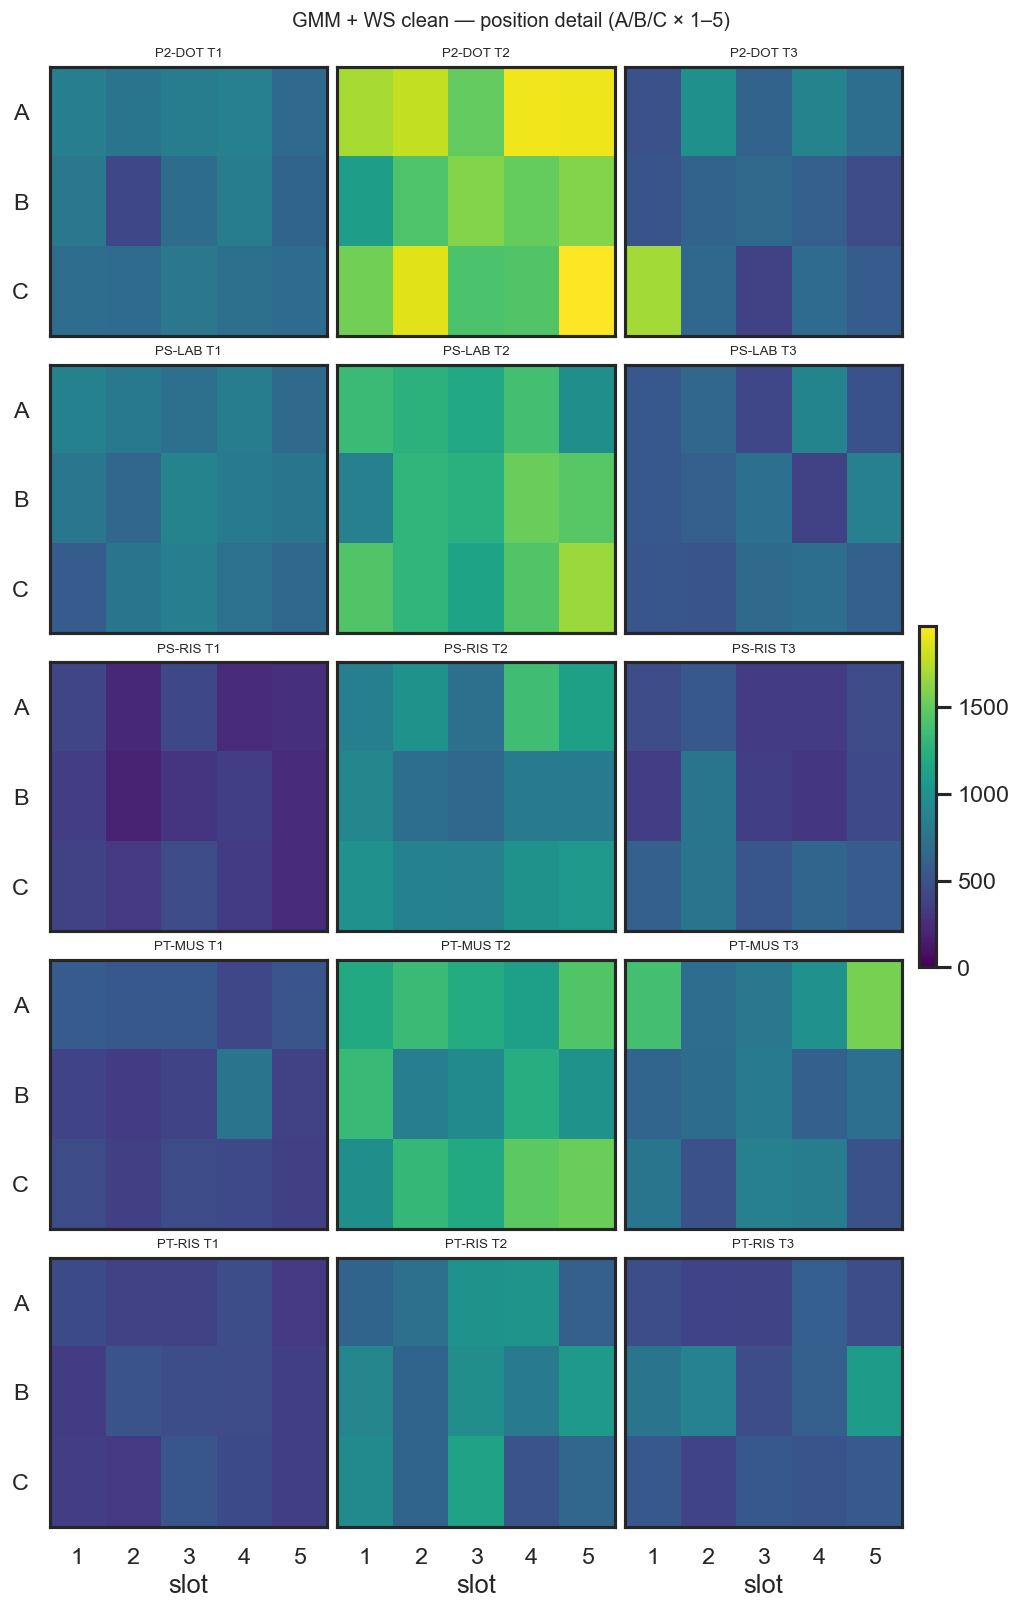

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_detail_gmm_ws_clean_count.png


**Figure 3.** Position mosaic for GMM + WS clean: each outer tile is one lab×period; inner grid is A/B/C × slots 1–5 (shared color scale). Saved as `summaries/heatmap_detail_gmm_ws_clean_count.png`.

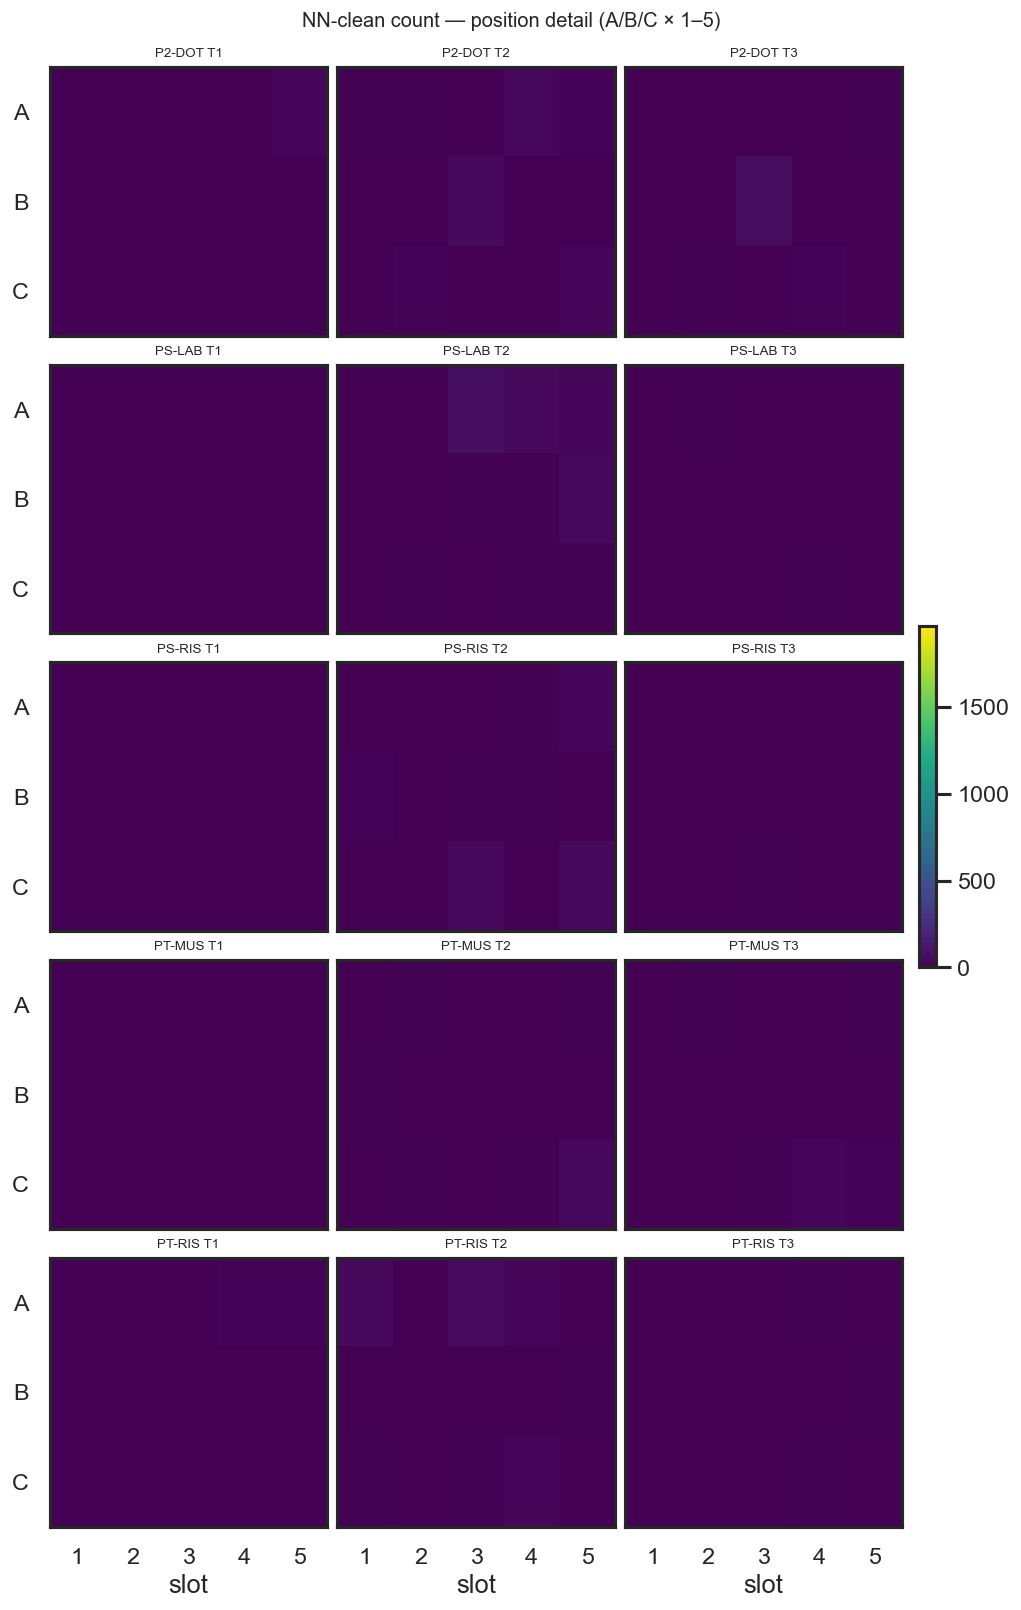

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_detail_nn_clean_count.png


**Figure 4.** Position mosaic for NN-clean count: each outer tile is one lab×period; inner grid is A/B/C × slots 1–5 (shared color scale). Saved as `summaries/heatmap_detail_nn_clean_count.png`.

In [8]:
_detail_panels = [
    (gmm_df, "imagej_count", "ImageJ macro (Summary.csv)"),
    (gmm_df, "gmm_ws_clean_count", "GMM + WS clean"),
    (radon_df, "nn_clean_count", "NN-clean count"),
]
(OUTPUT_DIR / "summaries").mkdir(parents=True, exist_ok=True)

_detail_values = []
for df, col, _title in _detail_panels:
    _detail_values.append(pd.to_numeric(df[col], errors="coerce"))
_detail_vmin = float(pd.concat(_detail_values).min())
_detail_vmax = float(pd.concat(_detail_values).max())
print(f"Shared detail scale: vmin={_detail_vmin:.4g}, vmax={_detail_vmax:.4g}")

for df, col, title in _detail_panels:
    fname = f"summaries/heatmap_detail_{col}.png"
    fig = plot_lab_period_position_heatmaps(
        df,
        col,
        title,
        save_path=OUTPUT_DIR / fname,
        vmin=_detail_vmin,
        vmax=_detail_vmax,
    )
    plt.show()
    plt.close(fig)
    print("Saved", OUTPUT_DIR / fname)
    fig_caption(
        f"Position mosaic for {title}: each outer tile is one lab×period; inner grid is A/B/C × slots 1–5 (shared color scale).",
        fname,
    )


## Detailed difference heatmap (GMM + WS clean − ImageJ macro)

Per-image difference vs original `Summary.csv` counts. Symmetric color scale centered at zero.

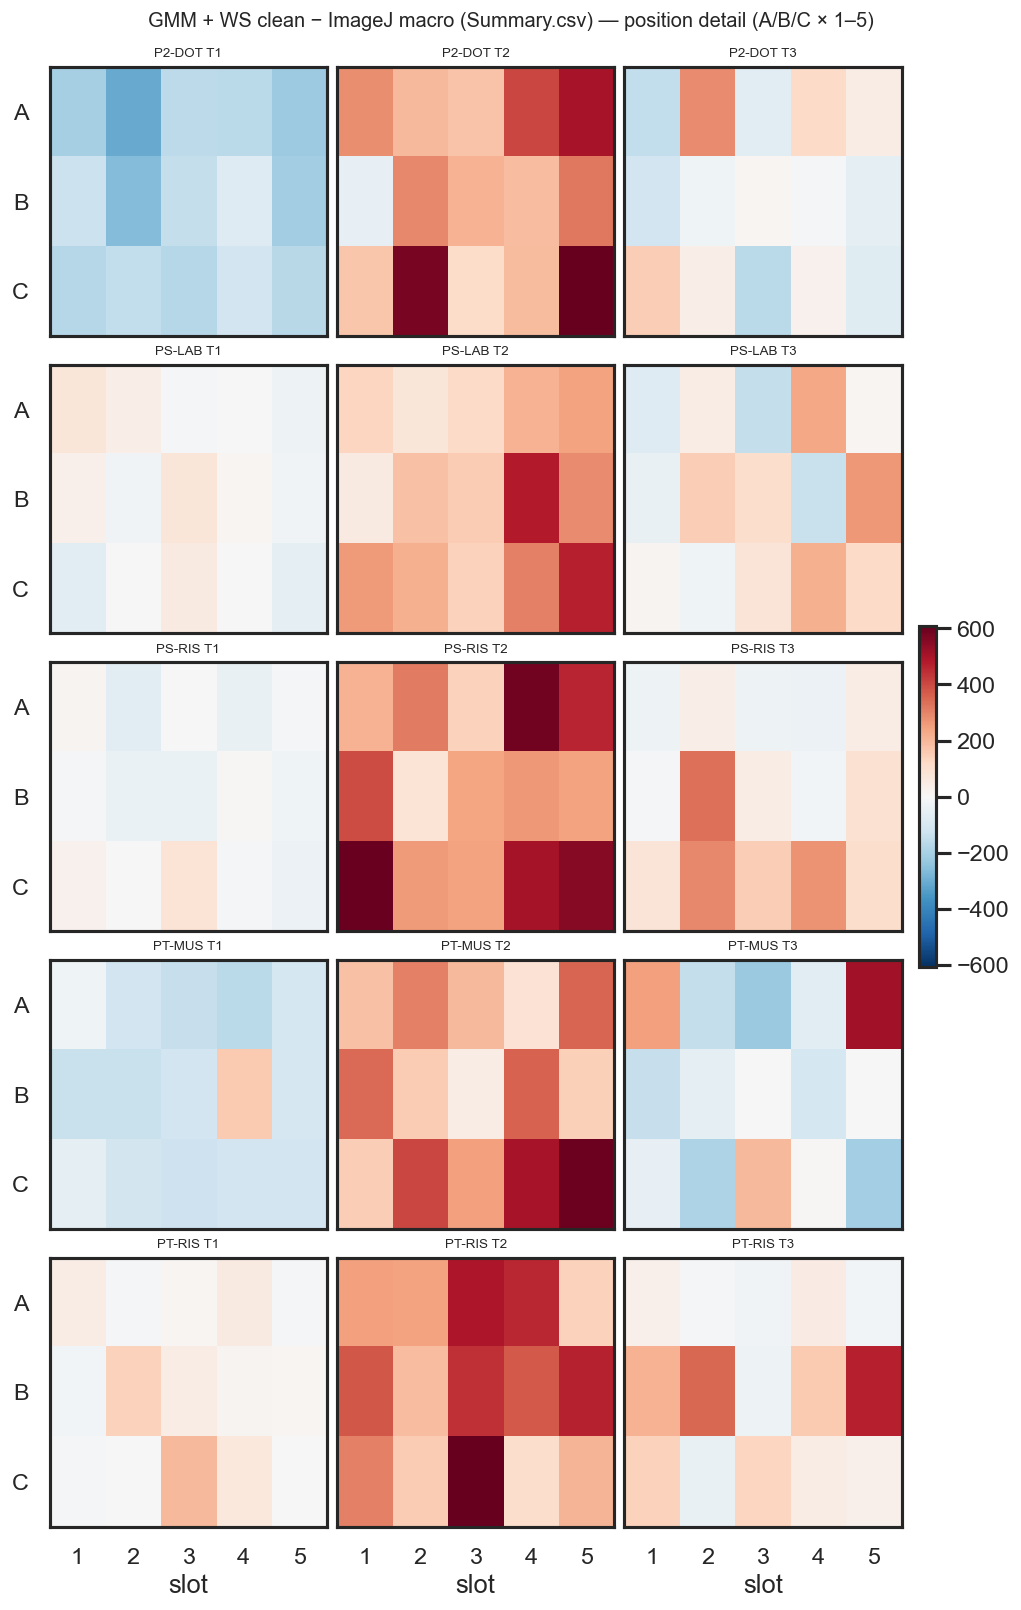

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_detail_gmm_minus_imagej.png


**Figure 5.** Per-position difference (GMM+WS clean minus ImageJ macro) on the lab×period mosaic; blue = GMM lower, red = GMM higher. Saved as `summaries/heatmap_detail_gmm_minus_imagej.png`.

In [9]:
_diff_df = gmm_df[
    ["image", "lab", "period", "position", "position_group", "gmm_ws_clean_count", "imagej_count"]
].copy()
_diff_df["gmm_minus_imagej"] = (
    pd.to_numeric(_diff_df["gmm_ws_clean_count"], errors="coerce")
    - pd.to_numeric(_diff_df["imagej_count"], errors="coerce")
)
_diff_abs = float(_diff_df["gmm_minus_imagej"].abs().max())

fig = plot_lab_period_position_heatmaps(
    _diff_df,
    "gmm_minus_imagej",
    "GMM + WS clean − ImageJ macro (Summary.csv)",
    save_path=OUTPUT_DIR / "summaries" / "heatmap_detail_gmm_minus_imagej.png",
    vmin=-_diff_abs,
    vmax=_diff_abs,
    cmap="RdBu_r",
)
plt.show()
plt.close(fig)
print("Saved", OUTPUT_DIR / "summaries" / "heatmap_detail_gmm_minus_imagej.png")
fig_caption(
    "Per-position difference (GMM+WS clean minus ImageJ macro) on the lab×period mosaic; blue = GMM lower, red = GMM higher.",
    "summaries/heatmap_detail_gmm_minus_imagej.png",
)


## Within-tile uniformity (ImageJ vs GMM + WS clean)

Each `(lab, period)` tile has 15 detector positions. We compare **spatial spread** across those positions:
- **Deviation mosaics**: each cell shows `value − tile_mean` (also z-score and percent variants).
- **Dispersion heatmaps**: per-tile `std`, `var`, and `CV = std/mean`.
- **Strip plots**: all 225 per-image deviations vs detector position.

Lower spread ⇒ more uniform counts across the 15 positions in that tile.

In [10]:
_UNIFORM_DIR = OUTPUT_DIR / "summaries"
_UNIFORM_DIR.mkdir(parents=True, exist_ok=True)

_METRIC_A = "imagej_count"
_METRIC_B = "gmm_ws_clean_count"
_LABEL_A = "ImageJ macro (Summary.csv)"
_LABEL_B = "GMM + WS clean"

_disp_a = tile_dispersion_table(gmm_df, _METRIC_A).rename(
    columns={c: f"imagej_{c}" for c in ["n", "mean", "std", "var", "cv"]}
)
_disp_b = tile_dispersion_table(gmm_df, _METRIC_B).rename(
    columns={c: f"gmm_{c}" for c in ["n", "mean", "std", "var", "cv"]}
)
_disp_compare = _disp_a.merge(_disp_b, on=["lab", "period"])
_disp_compare["std_gmm_minus_imagej"] = _disp_compare["gmm_std"] - _disp_compare["imagej_std"]
_disp_compare["cv_gmm_minus_imagej"] = _disp_compare["gmm_cv"] - _disp_compare["imagej_cv"]
_disp_compare.to_csv(_UNIFORM_DIR / "tile_dispersion_imagej_vs_gmm.csv", index=False)

_n_std_better = int((_disp_compare["gmm_std"] < _disp_compare["imagej_std"]).sum())
_n_cv_better = int((_disp_compare["gmm_cv"] < _disp_compare["imagej_cv"]).sum())
_n_tiles = len(_disp_compare)
print(f"Tiles where GMM std < ImageJ std: {_n_std_better}/{_n_tiles}")
print(f"Tiles where GMM CV  < ImageJ CV:  {_n_cv_better}/{_n_tiles}")
display(_disp_compare)

Tiles where GMM std < ImageJ std: 0/15
Tiles where GMM CV  < ImageJ CV:  0/15


,lab,period,imagej_n,imagej_mean,imagej_std,imagej_var,imagej_cv,gmm_n,gmm_mean,gmm_std,gmm_var,gmm_cv,std_gmm_minus_imagej,cv_gmm_minus_imagej
0,P2-DOT,T1,15,904.666667,98.388927,9680.380952,0.108757,15,727.866667,108.905507,11860.409524,0.149623,10.516580,0.040866
1,P2-DOT,T2,15,1341.333333,122.735876,15064.095238,0.091503,15,1619.266667,243.644784,59362.780952,0.150466,120.908908,0.058963
2,P2-DOT,T3,15,702.600000,239.805516,57506.685714,0.341312,15,703.866667,313.681792,98396.266667,0.445655,73.876276,0.104344
3,PS-LAB,T1,15,751.866667,52.910796,2799.552381,0.070373,15,757.133333,88.114266,7764.123810,0.116379,35.203469,0.046006
4,PS-LAB,T2,15,1077.733333,139.562821,19477.780952,0.129497,15,1299.066667,205.898542,42394.209524,0.158497,66.335721,0.029001
5,PS-LAB,T3,15,554.000000,60.535704,3664.571429,0.109270,15,607.800000,144.210758,20796.742857,0.237267,83.675055,0.127997
6,PS-RIS,T1,15,324.733333,54.802850,3003.352381,0.168763,15,315.866667,82.280762,6770.123810,0.260492,27.477912,0.091729
7,PS-RIS,T2,15,576.600000,100.270919,10054.257143,0.173900,15,916.466667,180.362677,32530.695238,0.196802,80.091758,0.022902
8,PS-RIS,T3,15,407.733333,65.047748,4231.209524,0.159535,15,496.533333,148.527952,22060.552381,0.299130,83.480203,0.139595
9,PT-MUS,T1,15,558.533333,65.350557,4270.695238,0.117004,15,464.933333,107.048365,11459.352381,0.230245,41.697808,0.113241


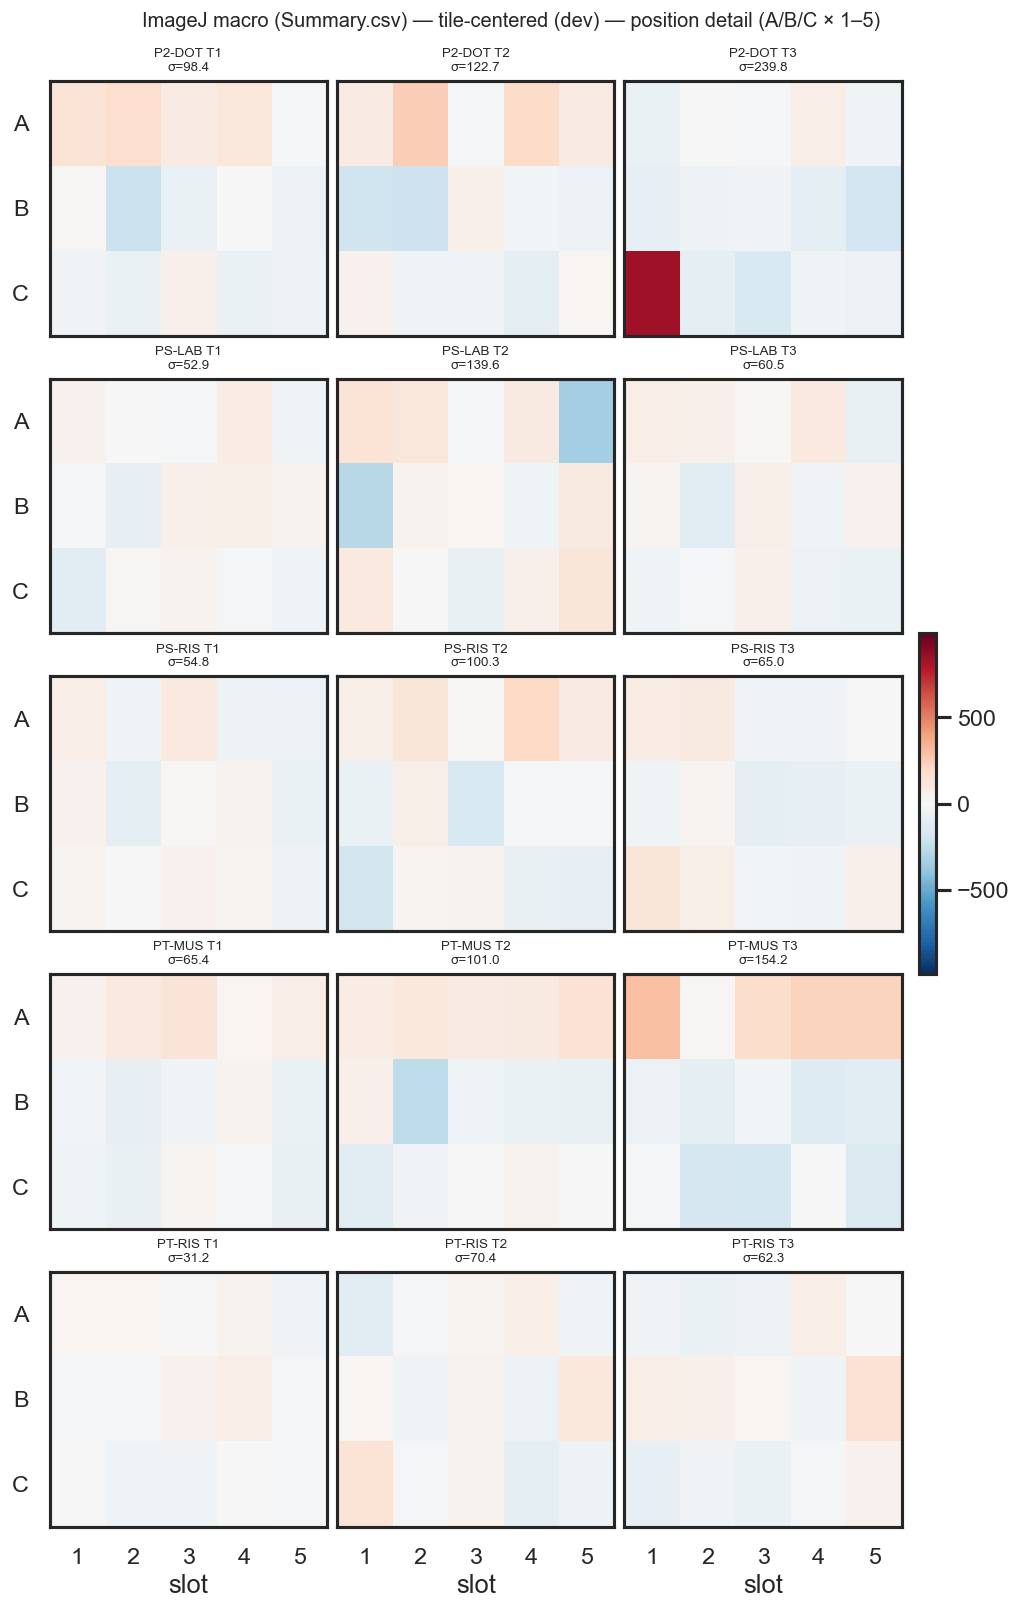

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_dev_imagej_count_dev.png


**Figure 6.** ImageJ macro (Summary.csv): count minus tile mean for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_dev_imagej_count_dev.png`.

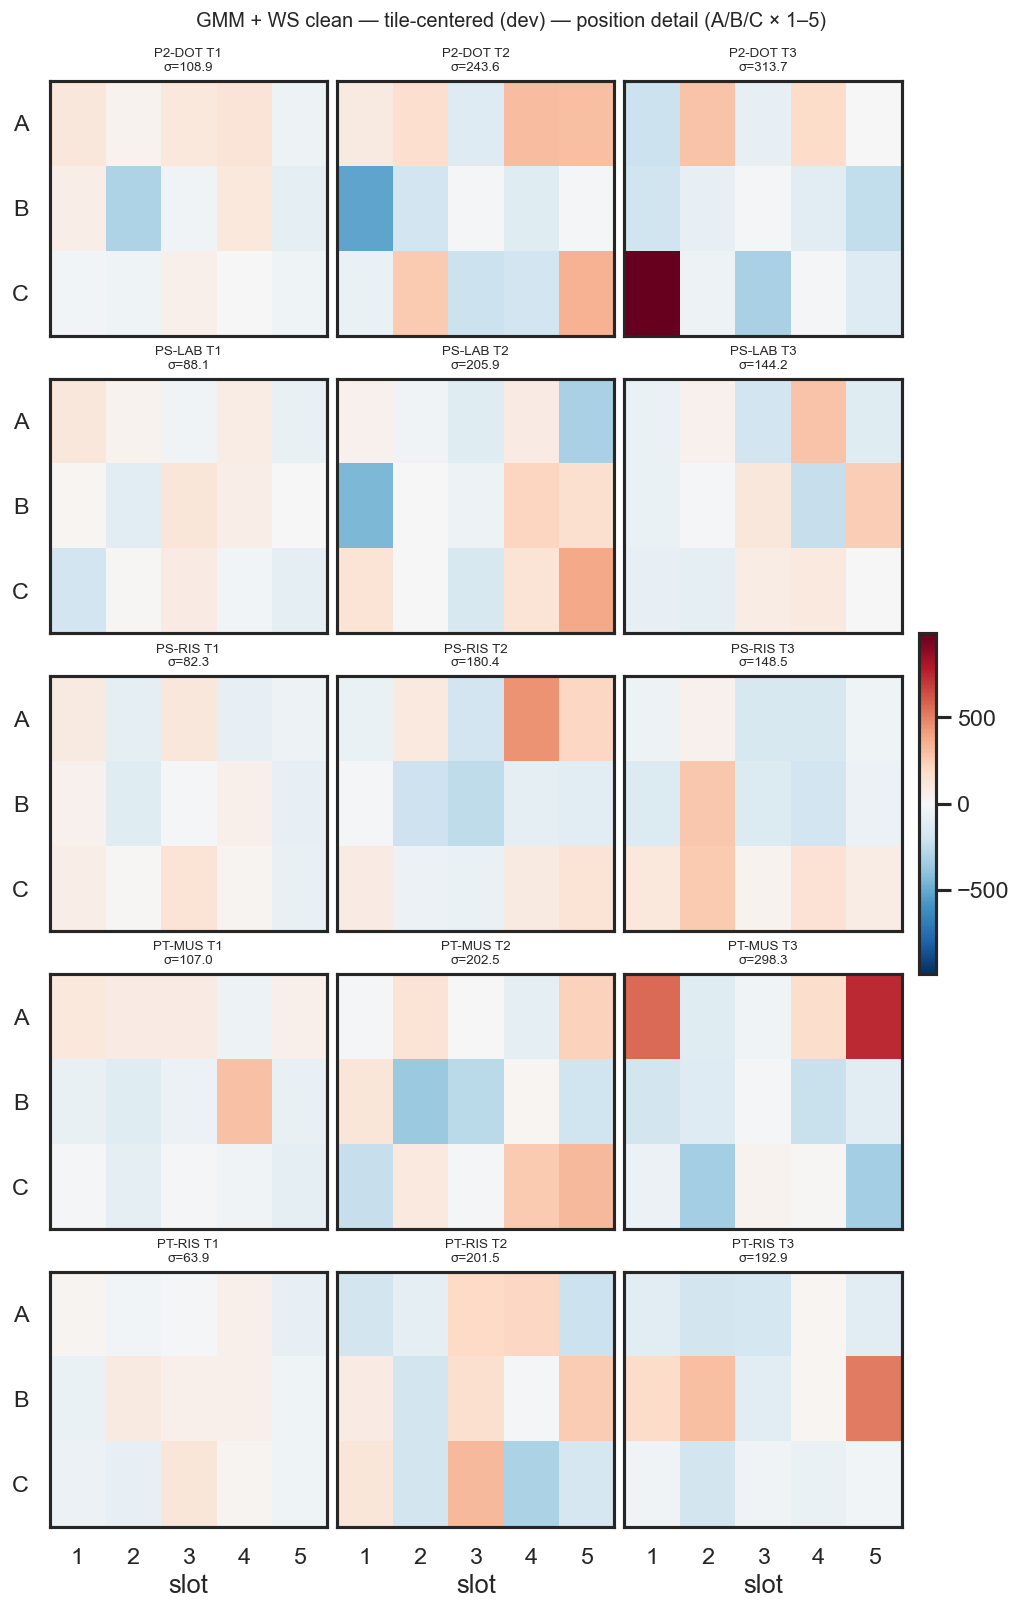

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_dev_gmm_ws_clean_count_dev.png


**Figure 7.** GMM + WS clean: count minus tile mean for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_dev_gmm_ws_clean_count_dev.png`.

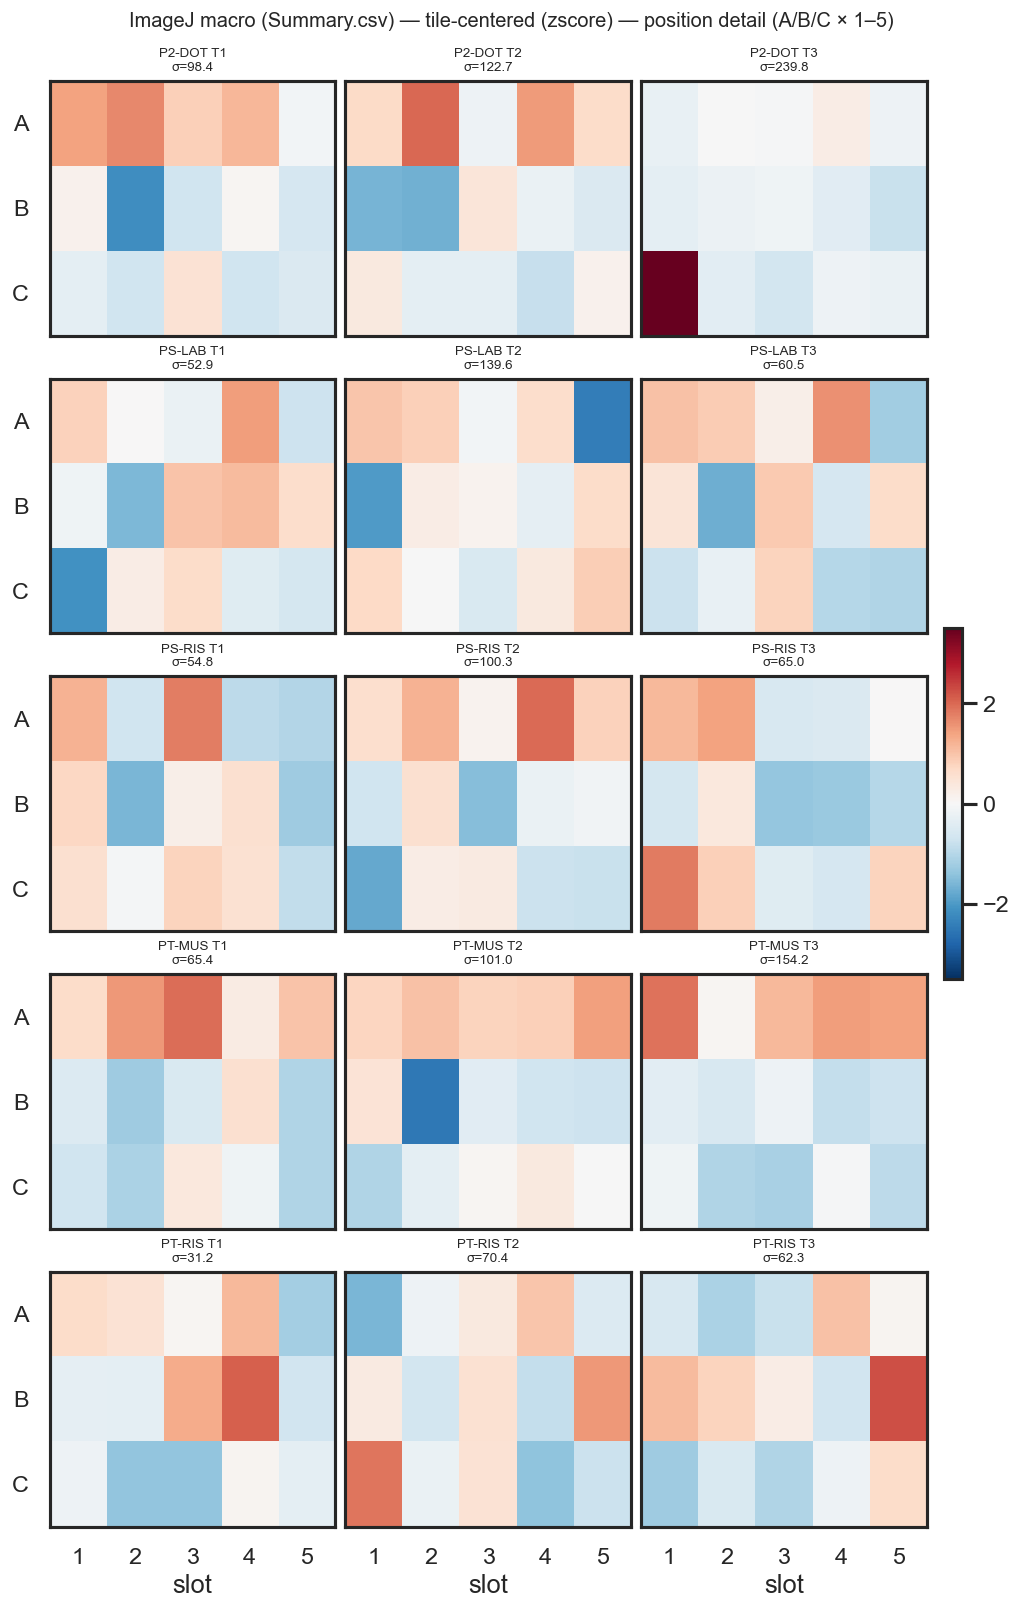

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_zscore_imagej_count_z.png


**Figure 8.** ImageJ macro (Summary.csv): z-score within tile for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_zscore_imagej_count_z.png`.

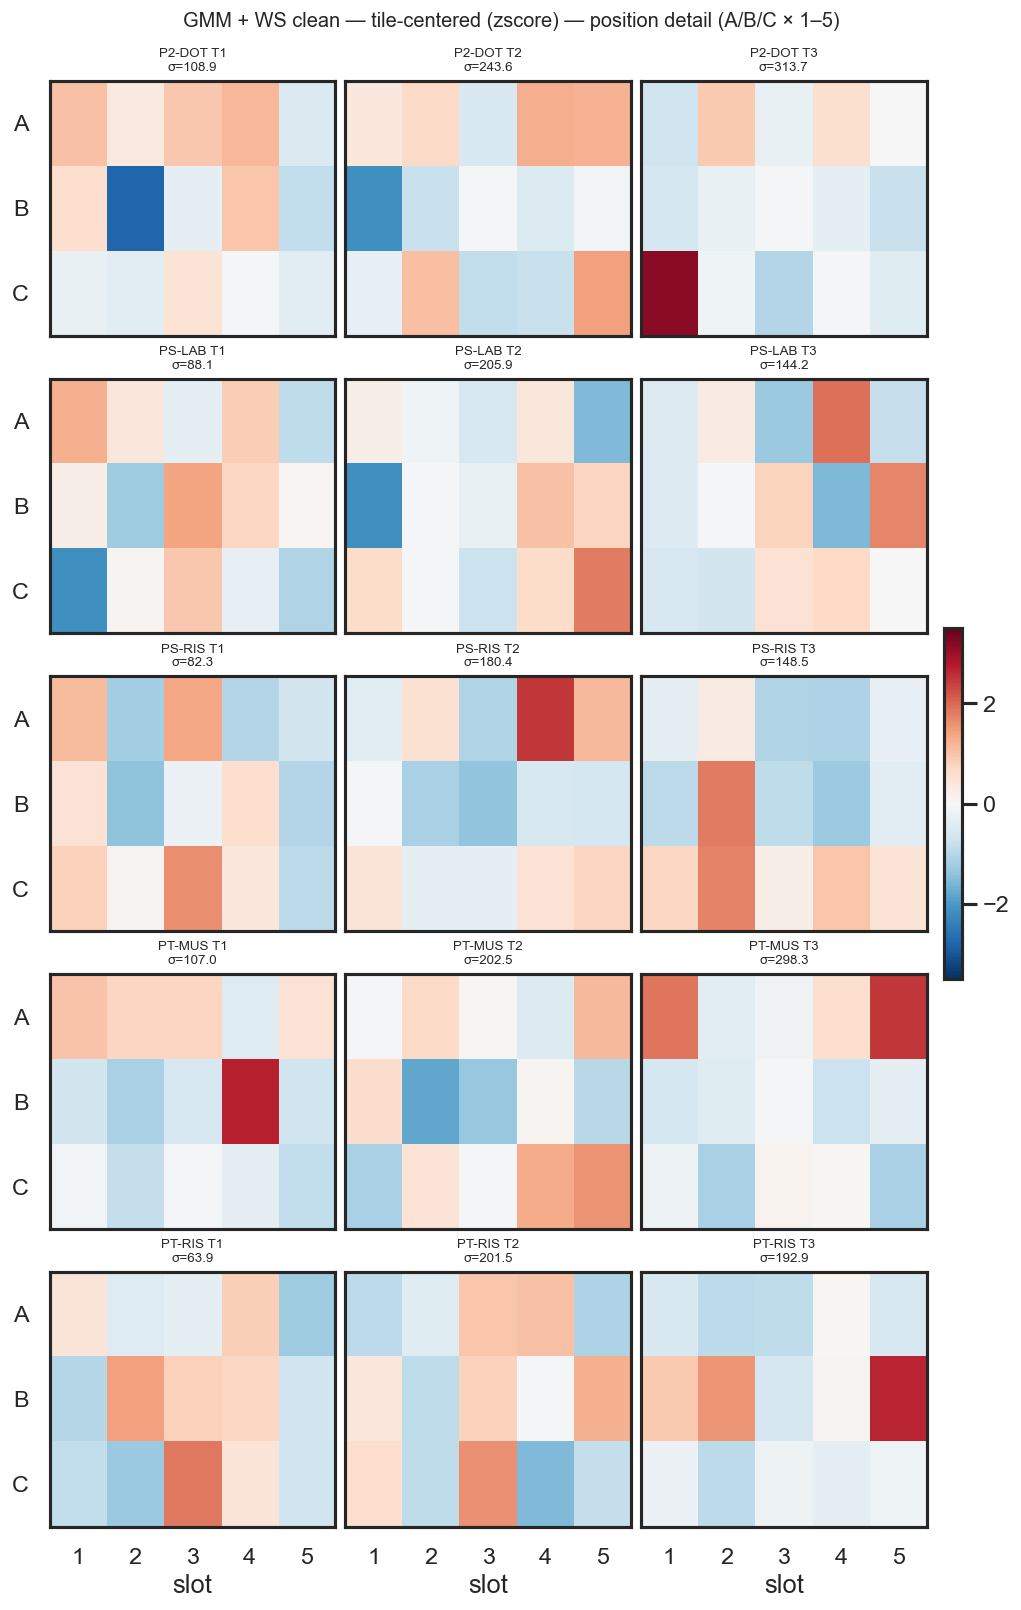

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_zscore_gmm_ws_clean_count_z.png


**Figure 9.** GMM + WS clean: z-score within tile for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_zscore_gmm_ws_clean_count_z.png`.

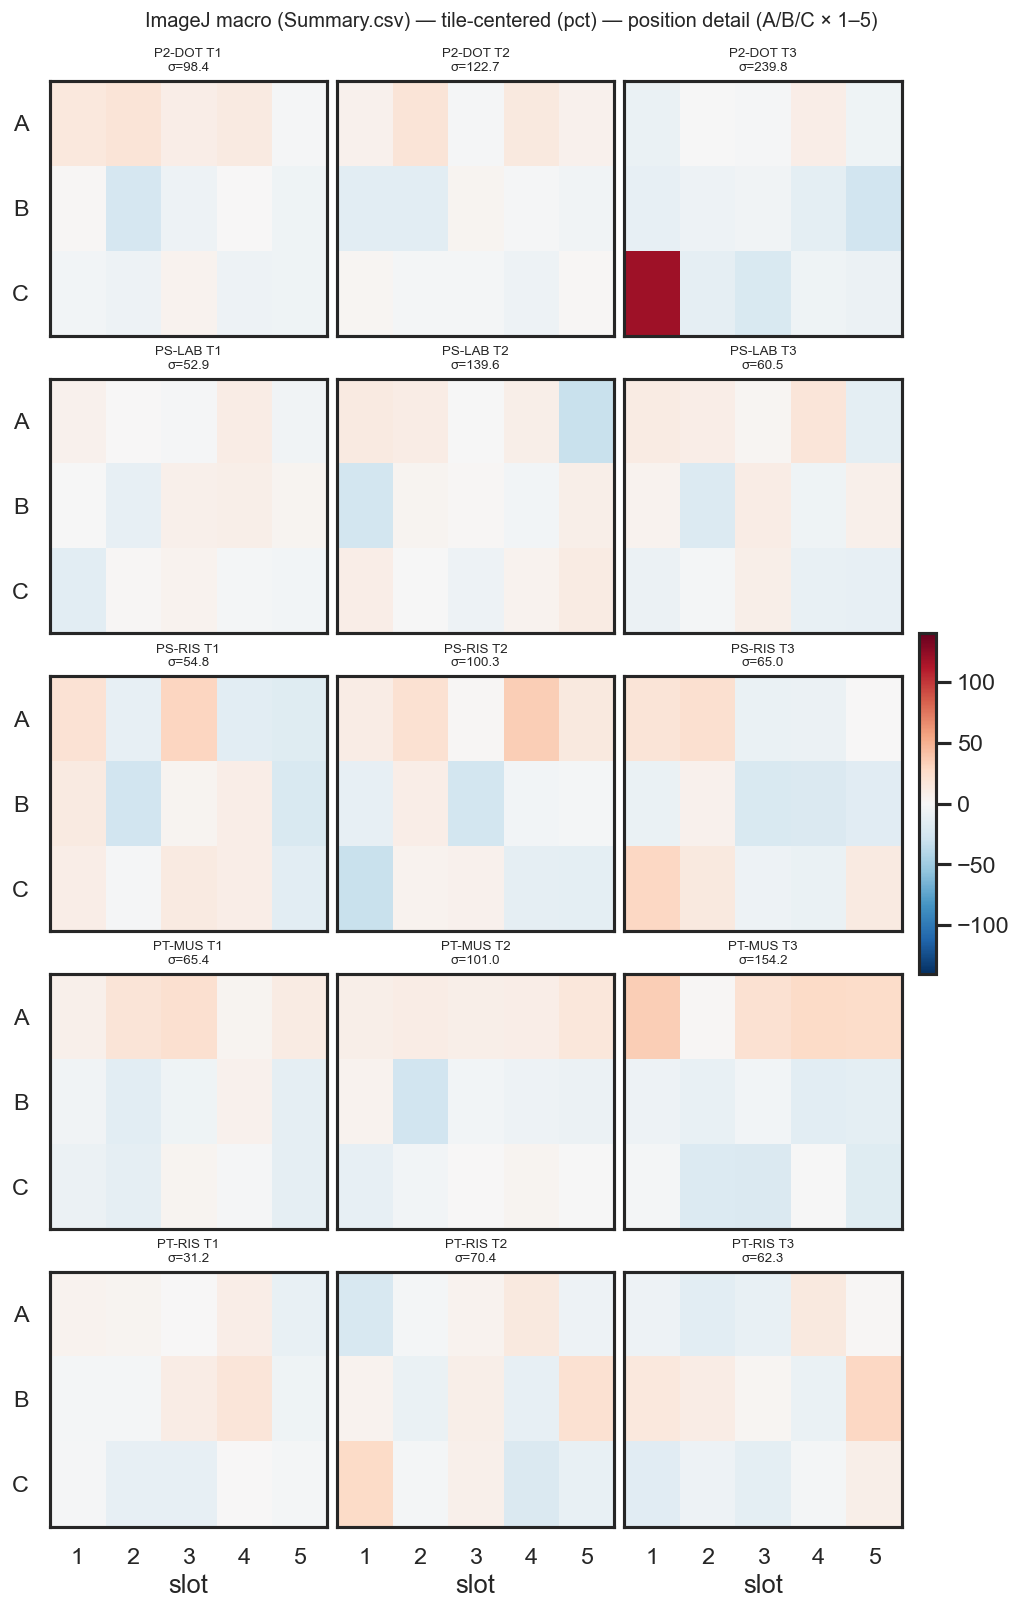

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_pct_imagej_count_pct_dev.png


**Figure 10.** ImageJ macro (Summary.csv): percent deviation from tile mean for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_pct_imagej_count_pct_dev.png`.

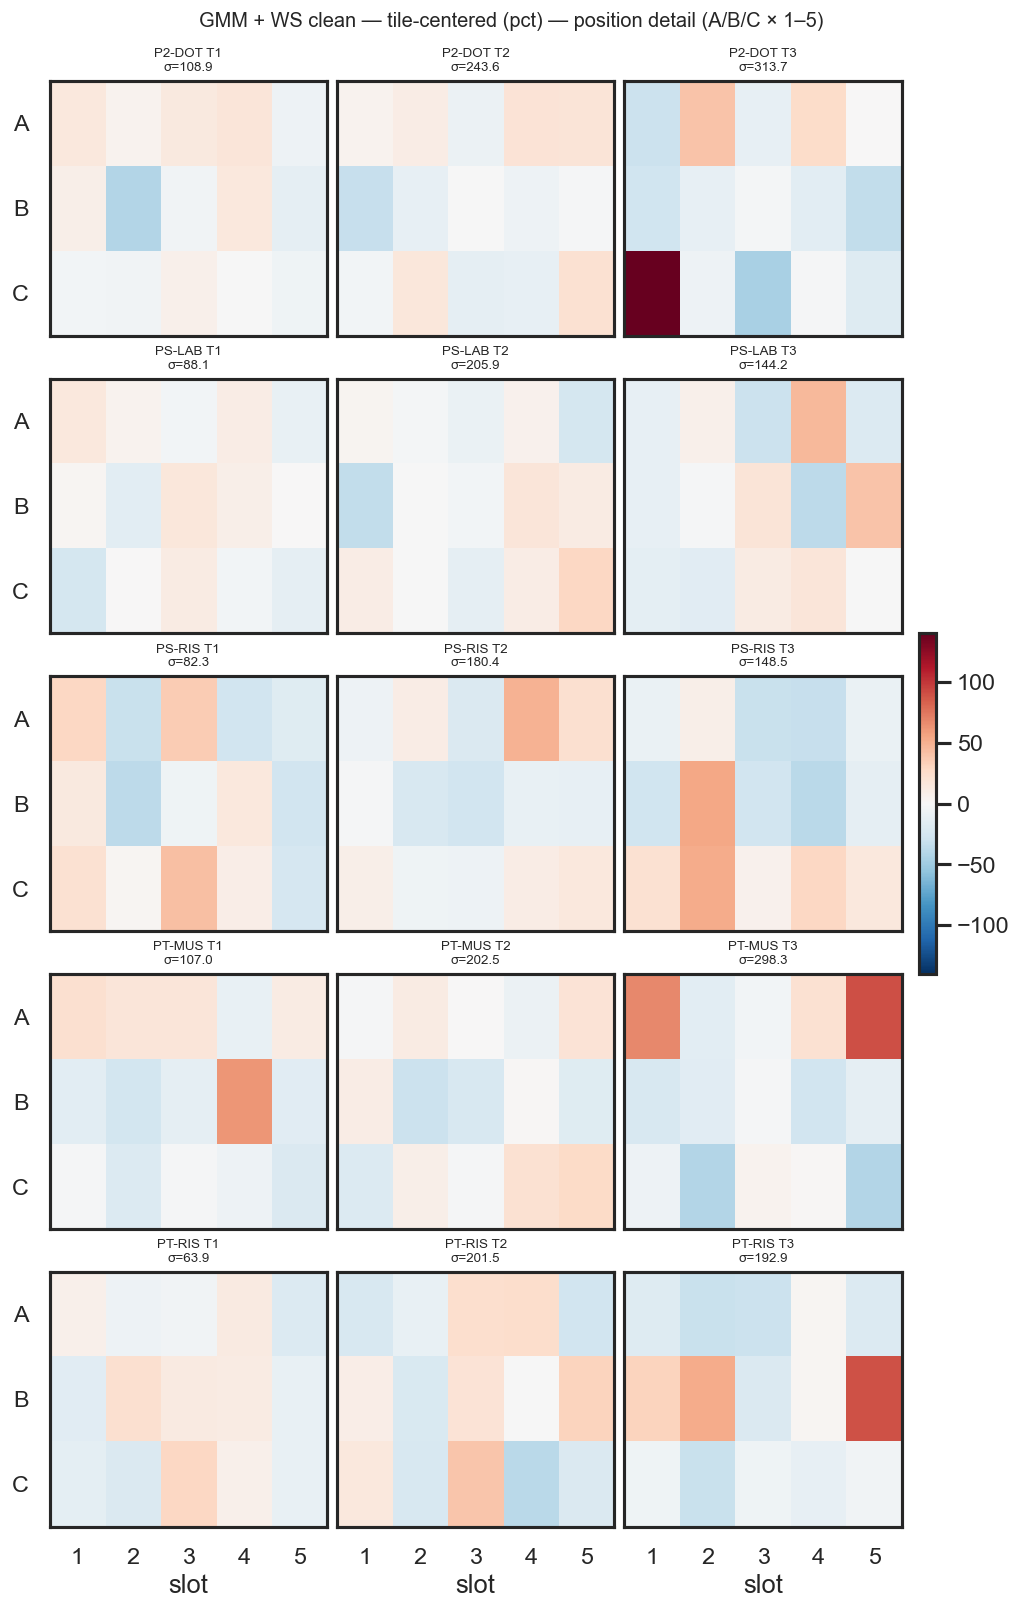

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/heatmap_deviation_pct_gmm_ws_clean_count_pct_dev.png


**Figure 11.** GMM + WS clean: percent deviation from tile mean for each detector slot; tile subtitle shows within-tile standard deviation. Saved as `summaries/heatmap_deviation_pct_gmm_ws_clean_count_pct_dev.png`.

In [11]:
def _plot_centered_mosaics(mode: str, cmap: str):
    panels = []
    for metric, label in [(_METRIC_A, _LABEL_A), (_METRIC_B, _LABEL_B)]:
        work, dev_col = add_within_tile_centered(gmm_df, metric, mode=mode)
        stats = tile_dispersion_table(gmm_df, metric)
        panels.append((work, dev_col, label, stats))

    vals = [pd.to_numeric(p[0][p[1]], errors="coerce") for p in panels]
    limit = float(max(v.abs().max() for v in vals))
    mode_labels = {
        "dev": "count minus tile mean",
        "zscore": "z-score within tile",
        "pct": "percent deviation from tile mean",
    }

    for work, dev_col, label, stats in panels:
        fname = f"heatmap_deviation_{mode}_{dev_col.replace('_tile_', '_')}.png"
        fig = plot_lab_period_position_heatmaps(
            work,
            dev_col,
            f"{label} — tile-centered ({mode})",
            save_path=_UNIFORM_DIR / fname,
            vmin=-limit,
            vmax=limit,
            cmap=cmap,
            tile_stats=stats,
            tile_stats_col="std",
        )
        plt.show()
        plt.close(fig)
        print("Saved", _UNIFORM_DIR / fname)
        fig_caption(
            f"{label}: {mode_labels[mode]} for each detector slot; tile subtitle shows within-tile standard deviation.",
            f"summaries/{fname}",
        )

_plot_centered_mosaics("dev", "RdBu_r")
_plot_centered_mosaics("zscore", "RdBu_r")
_plot_centered_mosaics("pct", "RdBu_r")


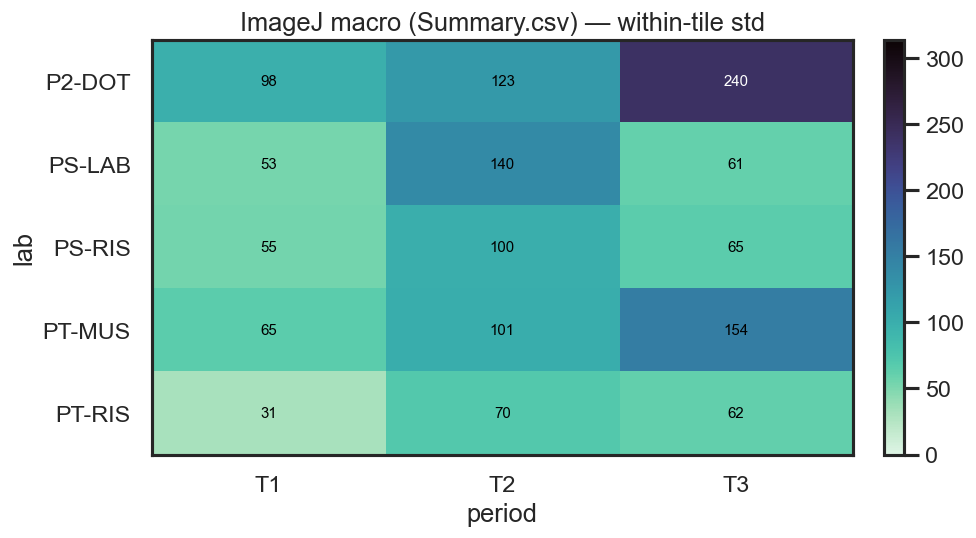

**Figure 12.** ImageJ macro (Summary.csv) — within-tile std: spread of per-position counts across the 15 slots in each lab×period tile (lower = more uniform). Saved as `summaries/heatmap_tile_std_imagej.png`.

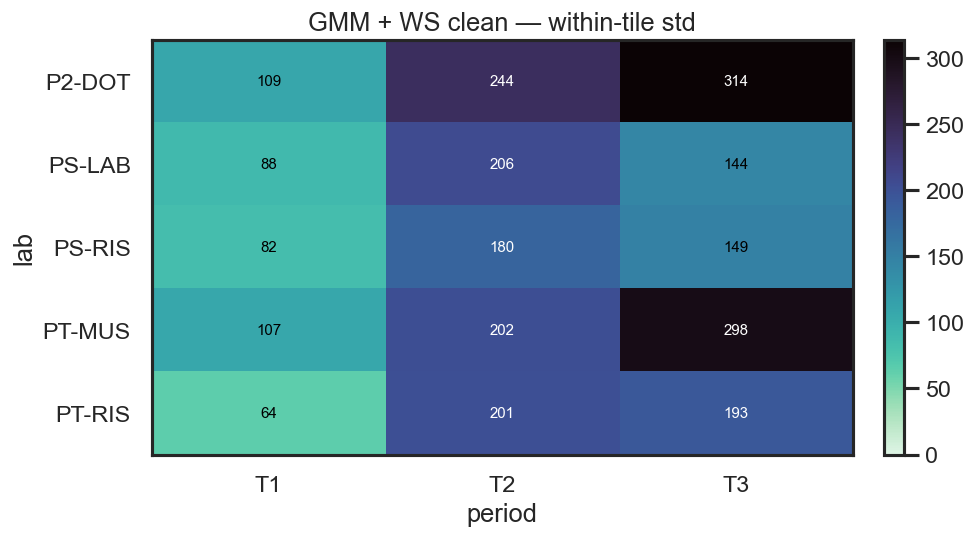

**Figure 13.** GMM + WS clean — within-tile std: spread of per-position counts across the 15 slots in each lab×period tile (lower = more uniform). Saved as `summaries/heatmap_tile_std_gmm.png`.

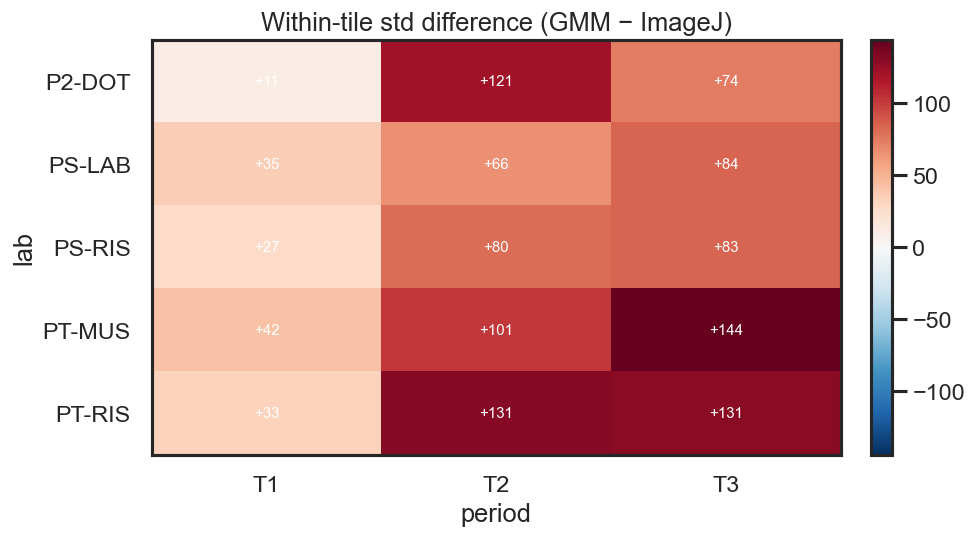

**Figure 14.** Difference in within-tile standard deviation (GMM minus ImageJ); positive values mean GMM is more variable across positions. Saved as `summaries/heatmap_tile_std_delta.png`.

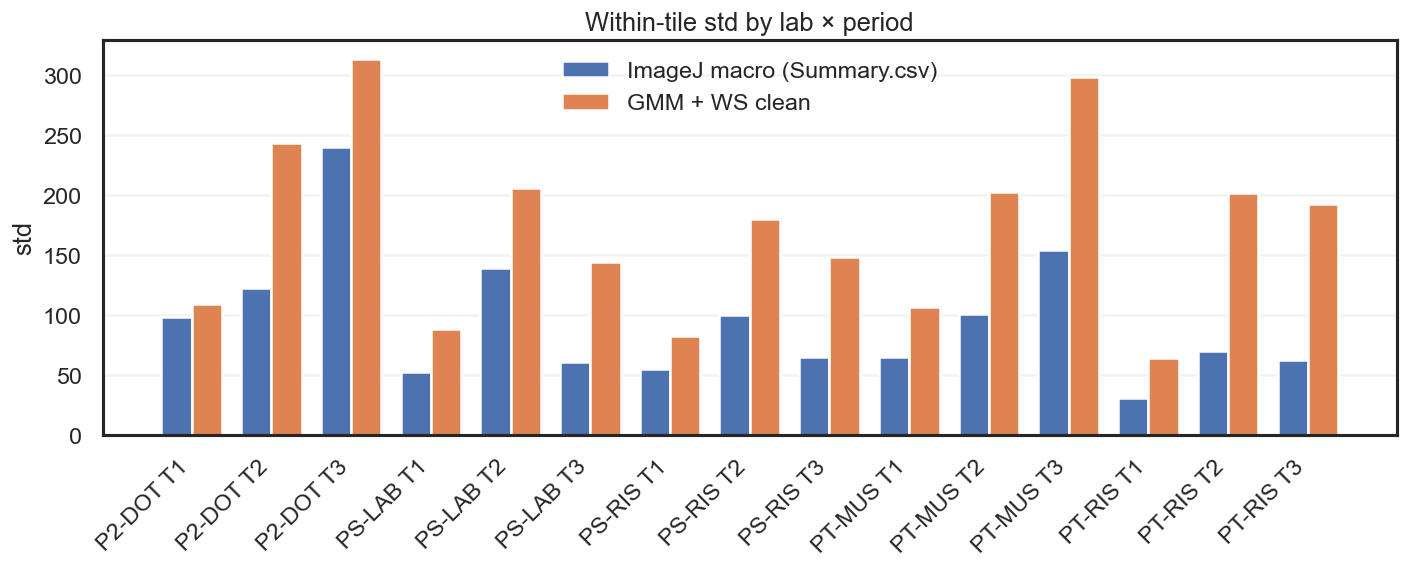

**Figure 15.** Grouped bars comparing within-tile standard deviation for ImageJ vs GMM+WS clean for each lab×period combination. Saved as `summaries/heatmap_tile_std_bars.png`.

Saved std comparison figures in /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries


In [12]:
_std_imagej = pivot_lab_period_dispersion(gmm_df, _METRIC_A, stat="std")
_std_gmm = pivot_lab_period_dispersion(gmm_df, _METRIC_B, stat="std")
_std_delta = _std_gmm - _std_imagej

_std_vmax = float(max(_std_imagej.max().max(), _std_gmm.max().max()))
for pivot, title, fname in [
    (_std_imagej, f"{_LABEL_A} — within-tile std", "heatmap_tile_std_imagej.png"),
    (_std_gmm, f"{_LABEL_B} — within-tile std", "heatmap_tile_std_gmm.png"),
]:
    fig = plot_lab_period_scalar_heatmaps(
        pivot, title, save_path=_UNIFORM_DIR / fname,
        cmap="mako_r", vmin=0, vmax=_std_vmax, annotate_fmt="{:.0f}",
    )
    plt.show(); plt.close(fig)
    fig_caption(
        f"{title}: spread of per-position counts across the 15 slots in each lab×period tile (lower = more uniform).",
        f"summaries/{fname}",
    )

_delta_abs = float(_std_delta.abs().max().max())
fig = plot_lab_period_scalar_heatmaps(
    _std_delta,
    "Within-tile std difference (GMM − ImageJ)",
    save_path=_UNIFORM_DIR / "heatmap_tile_std_delta.png",
    cmap="RdBu_r", vmin=-_delta_abs, vmax=_delta_abs, center=0, annotate_fmt="{:+.0f}",
)
plt.show(); plt.close(fig)
fig_caption(
    "Difference in within-tile standard deviation (GMM minus ImageJ); positive values mean GMM is more variable across positions.",
    "summaries/heatmap_tile_std_delta.png",
)

fig = plot_tile_dispersion_bars(
    tile_dispersion_table(gmm_df, _METRIC_A),
    tile_dispersion_table(gmm_df, _METRIC_B),
    stat_col="std",
    label_a=_LABEL_A,
    label_b=_LABEL_B,
    title="Within-tile std by lab × period",
    save_path=_UNIFORM_DIR / "heatmap_tile_std_bars.png",
)
plt.show(); plt.close(fig)
fig_caption(
    "Grouped bars comparing within-tile standard deviation for ImageJ vs GMM+WS clean for each lab×period combination.",
    "summaries/heatmap_tile_std_bars.png",
)
print("Saved std comparison figures in", _UNIFORM_DIR)


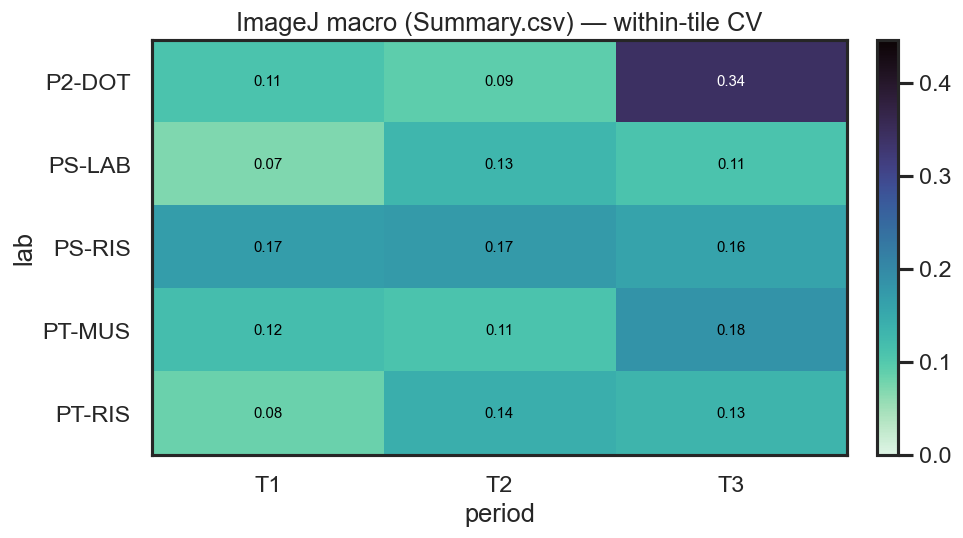

**Figure 16.** ImageJ macro (Summary.csv) — within-tile CV: coefficient of variation (std/mean) across the 15 positions in each tile. Saved as `summaries/heatmap_tile_cv_imagej.png`.

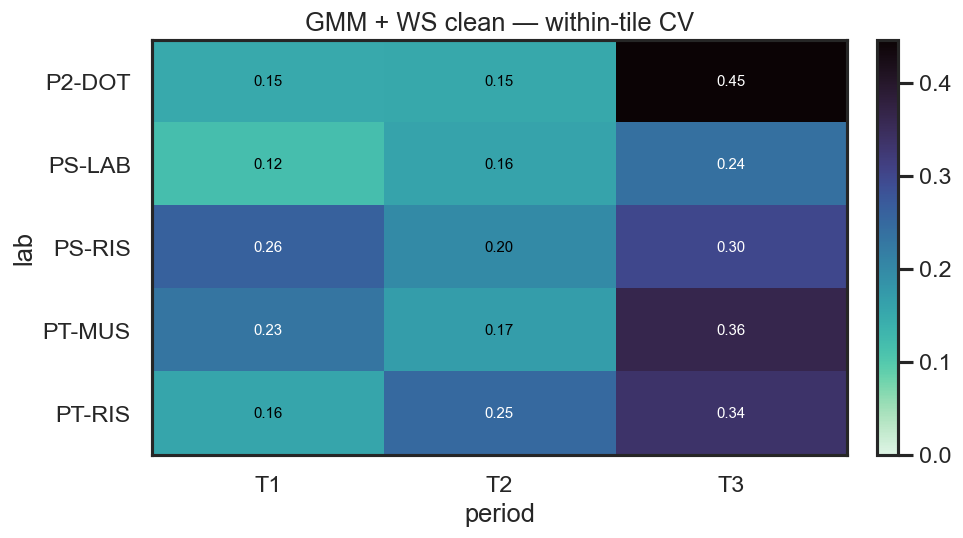

**Figure 17.** GMM + WS clean — within-tile CV: coefficient of variation (std/mean) across the 15 positions in each tile. Saved as `summaries/heatmap_tile_cv_gmm.png`.

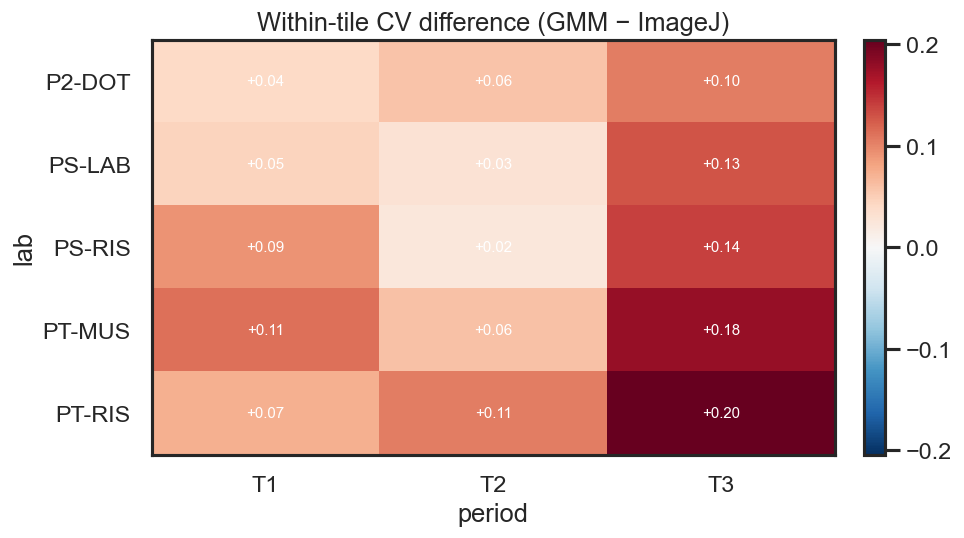

**Figure 18.** Difference in within-tile CV (GMM minus ImageJ); normalizes spread by the tile mean count. Saved as `summaries/heatmap_tile_cv_delta.png`.

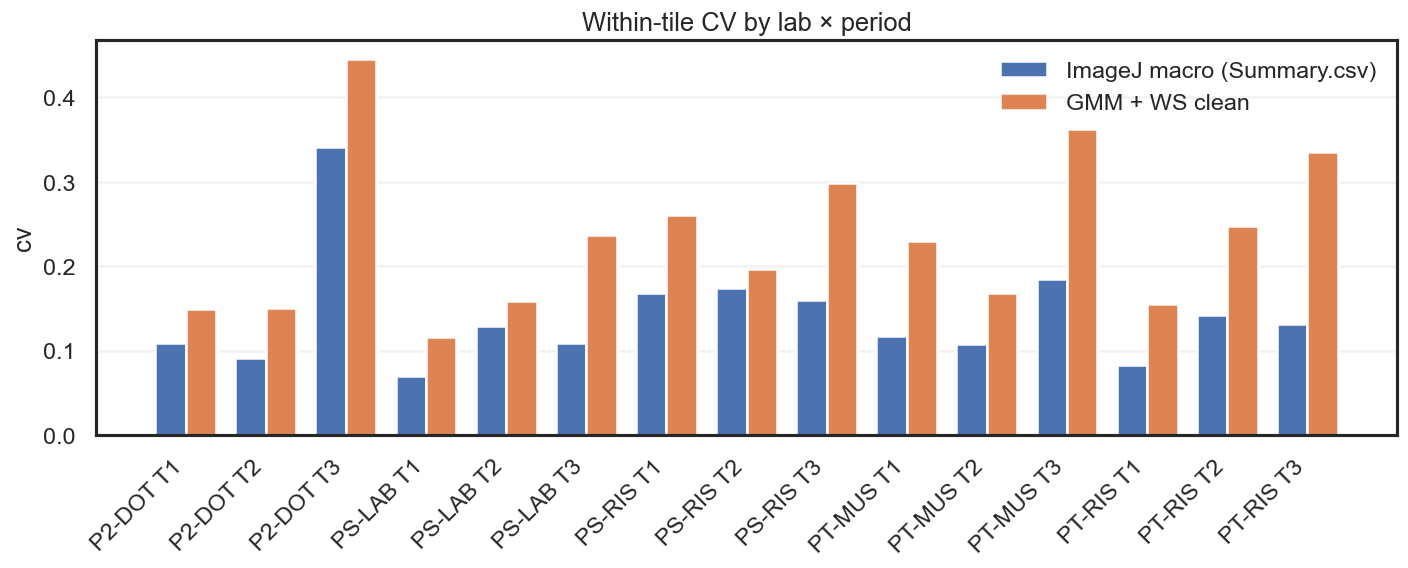

**Figure 19.** Grouped bars comparing within-tile CV for ImageJ vs GMM+WS clean. Saved as `summaries/heatmap_tile_cv_bars.png`.

Saved CV comparison figures in /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries


In [13]:
_cv_imagej = pivot_lab_period_dispersion(gmm_df, _METRIC_A, stat="cv")
_cv_gmm = pivot_lab_period_dispersion(gmm_df, _METRIC_B, stat="cv")
_cv_delta = _cv_gmm - _cv_imagej

_cv_vmax = float(max(_cv_imagej.max().max(), _cv_gmm.max().max()))
for pivot, title, fname in [
    (_cv_imagej, f"{_LABEL_A} — within-tile CV", "heatmap_tile_cv_imagej.png"),
    (_cv_gmm, f"{_LABEL_B} — within-tile CV", "heatmap_tile_cv_gmm.png"),
]:
    fig = plot_lab_period_scalar_heatmaps(
        pivot, title, save_path=_UNIFORM_DIR / fname,
        cmap="mako_r", vmin=0, vmax=_cv_vmax, annotate_fmt="{:.2f}",
    )
    plt.show(); plt.close(fig)
    fig_caption(
        f"{title}: coefficient of variation (std/mean) across the 15 positions in each tile.",
        f"summaries/{fname}",
    )

_cv_delta_abs = float(_cv_delta.abs().max().max())
fig = plot_lab_period_scalar_heatmaps(
    _cv_delta,
    "Within-tile CV difference (GMM − ImageJ)",
    save_path=_UNIFORM_DIR / "heatmap_tile_cv_delta.png",
    cmap="RdBu_r", vmin=-_cv_delta_abs, vmax=_cv_delta_abs, center=0, annotate_fmt="{:+.2f}",
)
plt.show(); plt.close(fig)
fig_caption(
    "Difference in within-tile CV (GMM minus ImageJ); normalizes spread by the tile mean count.",
    "summaries/heatmap_tile_cv_delta.png",
)

fig = plot_tile_dispersion_bars(
    tile_dispersion_table(gmm_df, _METRIC_A),
    tile_dispersion_table(gmm_df, _METRIC_B),
    stat_col="cv",
    label_a=_LABEL_A,
    label_b=_LABEL_B,
    title="Within-tile CV by lab × period",
    save_path=_UNIFORM_DIR / "heatmap_tile_cv_bars.png",
)
plt.show(); plt.close(fig)
fig_caption(
    "Grouped bars comparing within-tile CV for ImageJ vs GMM+WS clean.",
    "summaries/heatmap_tile_cv_bars.png",
)
print("Saved CV comparison figures in", _UNIFORM_DIR)


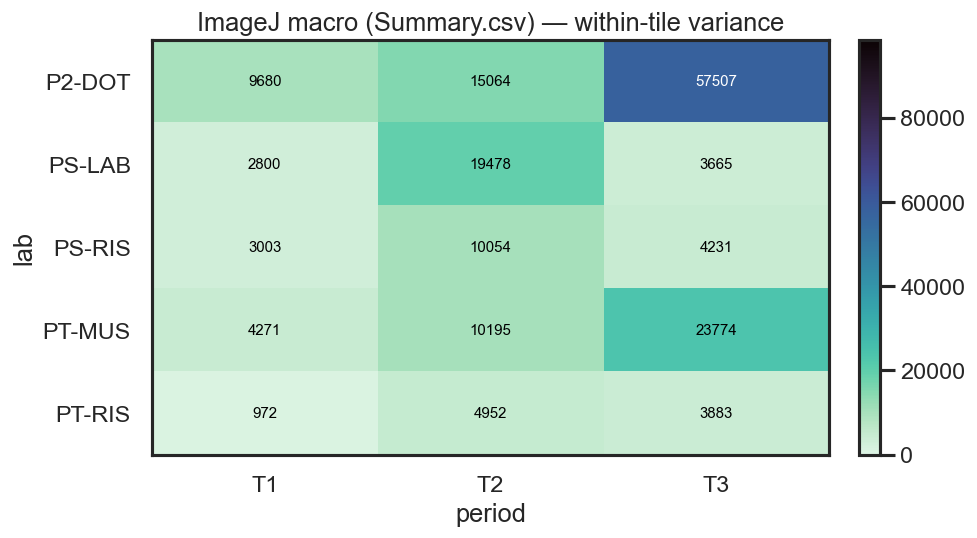

**Figure 20.** ImageJ macro (Summary.csv) — within-tile variance: variance of per-position counts across the 15 slots in each lab×period tile. Saved as `summaries/heatmap_tile_var_imagej.png`.

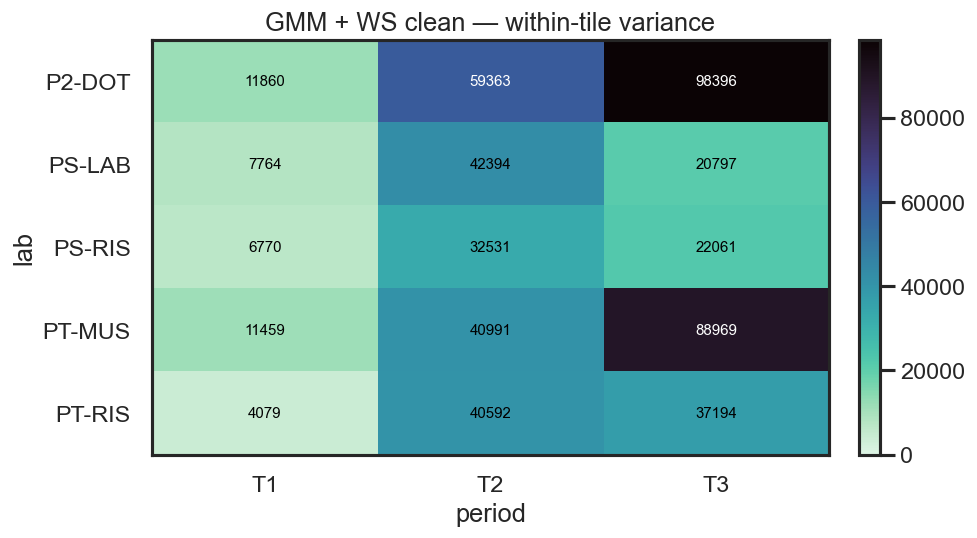

**Figure 21.** GMM + WS clean — within-tile variance: variance of per-position counts across the 15 slots in each lab×period tile. Saved as `summaries/heatmap_tile_var_gmm.png`.

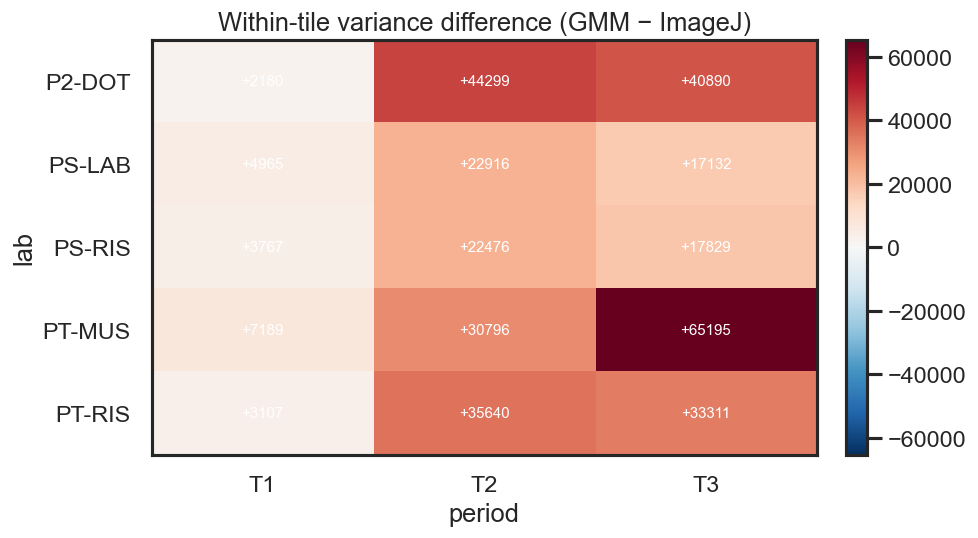

**Figure 22.** Difference in within-tile variance (GMM minus ImageJ). Saved as `summaries/heatmap_tile_var_delta.png`.

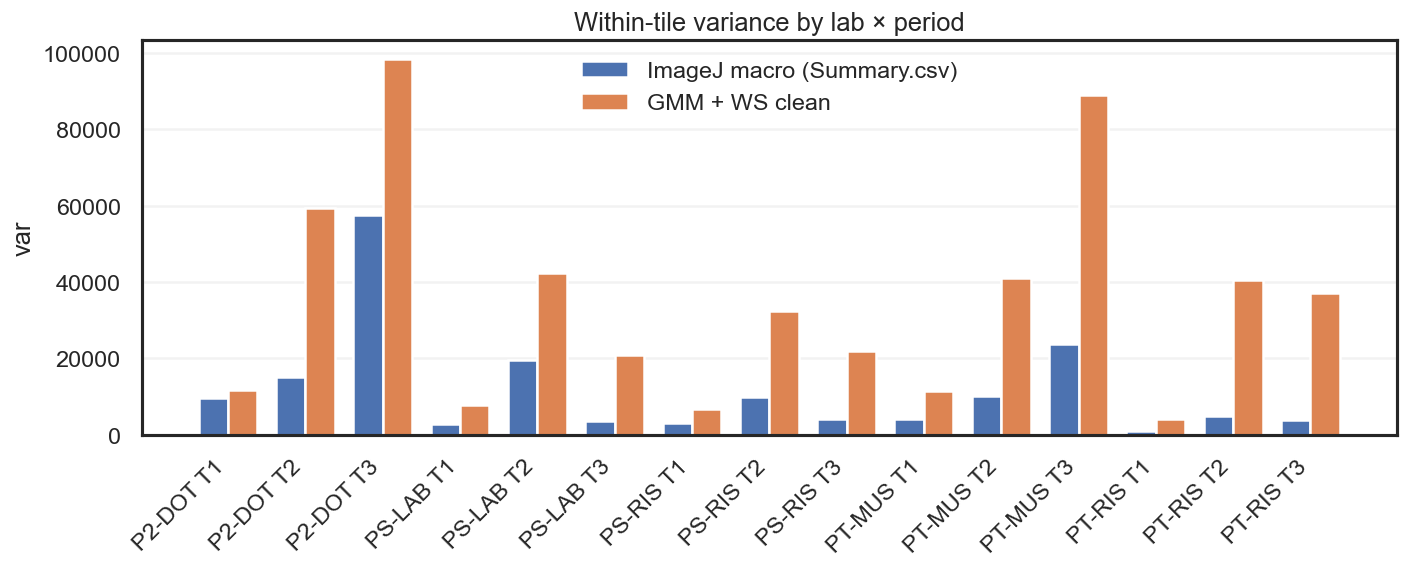

**Figure 23.** Grouped bars comparing within-tile variance for ImageJ vs GMM+WS clean. Saved as `summaries/heatmap_tile_var_bars.png`.

Saved variance comparison figures in /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries


In [14]:
_var_imagej = pivot_lab_period_dispersion(gmm_df, _METRIC_A, stat="var")
_var_gmm = pivot_lab_period_dispersion(gmm_df, _METRIC_B, stat="var")
_var_delta = _var_gmm - _var_imagej

_var_vmax = float(max(_var_imagej.max().max(), _var_gmm.max().max()))
for pivot, title, fname in [
    (_var_imagej, f"{_LABEL_A} — within-tile variance", "heatmap_tile_var_imagej.png"),
    (_var_gmm, f"{_LABEL_B} — within-tile variance", "heatmap_tile_var_gmm.png"),
]:
    fig = plot_lab_period_scalar_heatmaps(
        pivot, title, save_path=_UNIFORM_DIR / fname,
        cmap="mako_r", vmin=0, vmax=_var_vmax, annotate_fmt="{:.0f}",
    )
    plt.show(); plt.close(fig)
    fig_caption(
        f"{title}: variance of per-position counts across the 15 slots in each lab×period tile.",
        f"summaries/{fname}",
    )

_var_delta_abs = float(_var_delta.abs().max().max())
fig = plot_lab_period_scalar_heatmaps(
    _var_delta,
    "Within-tile variance difference (GMM − ImageJ)",
    save_path=_UNIFORM_DIR / "heatmap_tile_var_delta.png",
    cmap="RdBu_r", vmin=-_var_delta_abs, vmax=_var_delta_abs, center=0, annotate_fmt="{:+.0f}",
)
plt.show(); plt.close(fig)
fig_caption(
    "Difference in within-tile variance (GMM minus ImageJ).",
    "summaries/heatmap_tile_var_delta.png",
)

fig = plot_tile_dispersion_bars(
    tile_dispersion_table(gmm_df, _METRIC_A),
    tile_dispersion_table(gmm_df, _METRIC_B),
    stat_col="var",
    label_a=_LABEL_A,
    label_b=_LABEL_B,
    title="Within-tile variance by lab × period",
    save_path=_UNIFORM_DIR / "heatmap_tile_var_bars.png",
)
plt.show(); plt.close(fig)
fig_caption(
    "Grouped bars comparing within-tile variance for ImageJ vs GMM+WS clean.",
    "summaries/heatmap_tile_var_bars.png",
)
print("Saved variance comparison figures in", _UNIFORM_DIR)


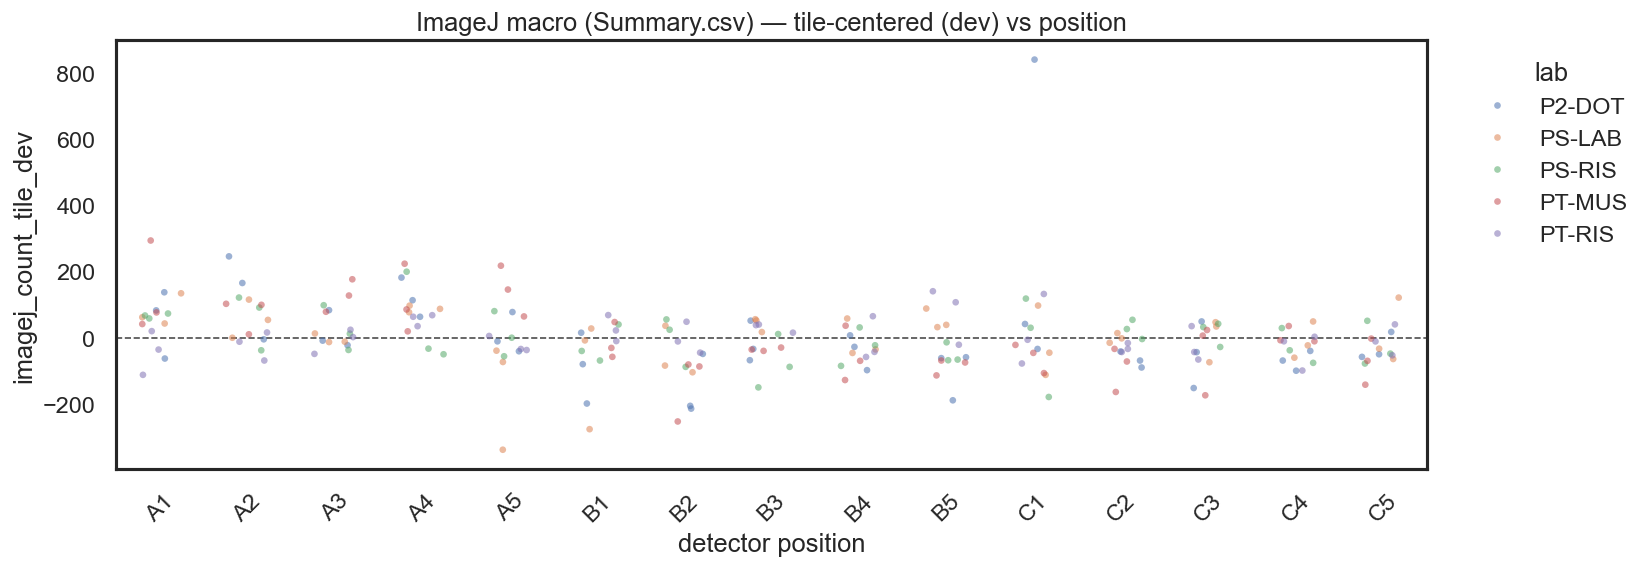

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/strip_deviation_dev_imagej_count.png


**Figure 24.** ImageJ macro (Summary.csv): distribution of tile-centered (dev) deviations vs detector position (A1…C5), points colored by lab. Saved as `summaries/strip_deviation_dev_imagej_count.png`.

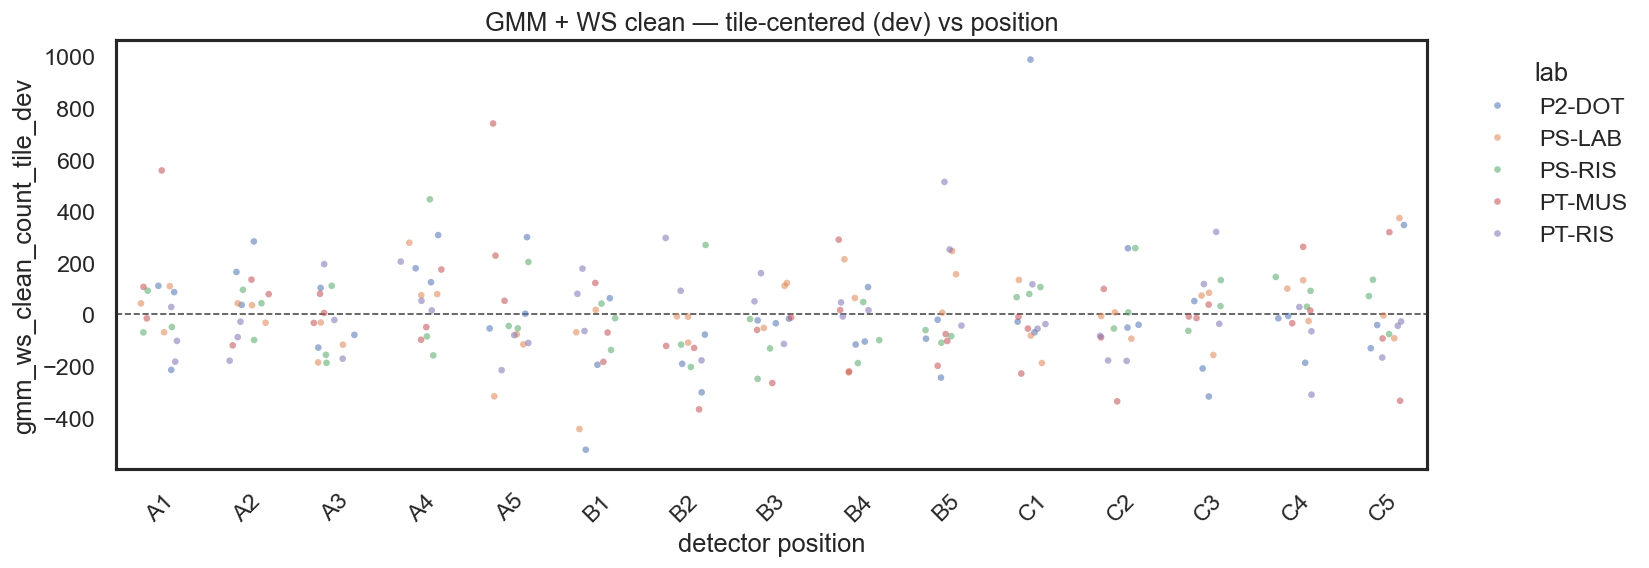

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/strip_deviation_dev_gmm_ws_clean_count.png


**Figure 25.** GMM + WS clean: distribution of tile-centered (dev) deviations vs detector position (A1…C5), points colored by lab. Saved as `summaries/strip_deviation_dev_gmm_ws_clean_count.png`.

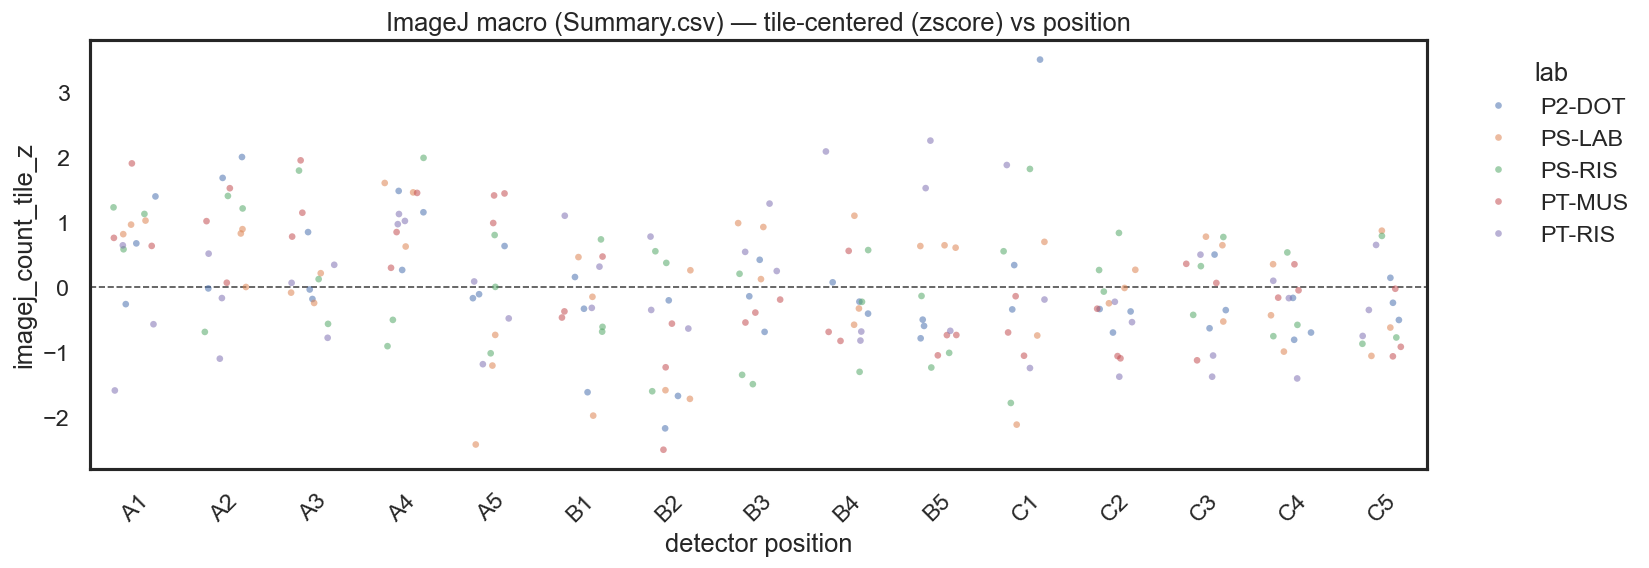

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/strip_deviation_zscore_imagej_count.png


**Figure 26.** ImageJ macro (Summary.csv): distribution of tile-centered (zscore) deviations vs detector position (A1…C5), points colored by lab. Saved as `summaries/strip_deviation_zscore_imagej_count.png`.

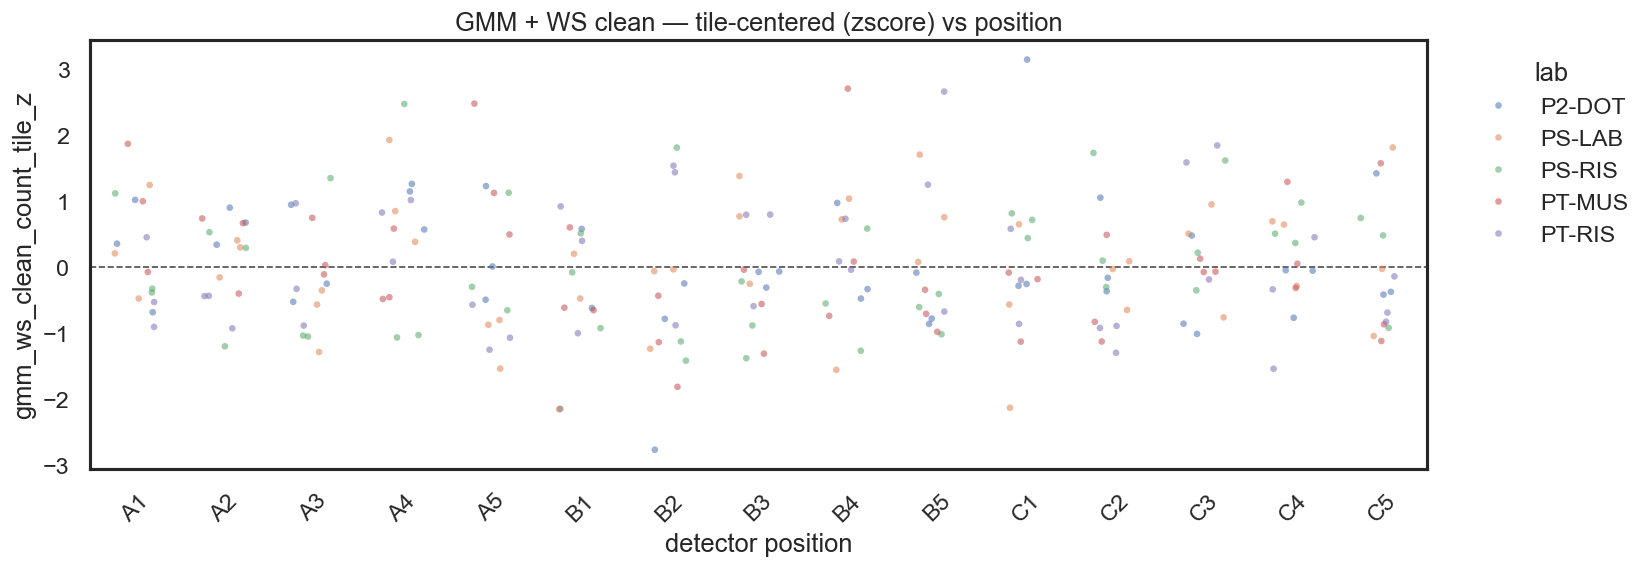

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/strip_deviation_zscore_gmm_ws_clean_count.png


**Figure 27.** GMM + WS clean: distribution of tile-centered (zscore) deviations vs detector position (A1…C5), points colored by lab. Saved as `summaries/strip_deviation_zscore_gmm_ws_clean_count.png`.

In [15]:
for metric, label, mode in [
    (_METRIC_A, _LABEL_A, "dev"),
    (_METRIC_B, _LABEL_B, "dev"),
    (_METRIC_A, _LABEL_A, "zscore"),
    (_METRIC_B, _LABEL_B, "zscore"),
]:
    work, dev_col = add_within_tile_centered(gmm_df, metric, mode=mode)
    fname = f"strip_deviation_{mode}_{metric}.png"
    fig = plot_deviation_strip(
        work,
        dev_col,
        f"{label} — tile-centered ({mode}) vs position",
        save_path=_UNIFORM_DIR / fname,
    )
    plt.show()
    plt.close(fig)
    print("Saved", _UNIFORM_DIR / fname)
    fig_caption(
        f"{label}: distribution of tile-centered ({mode}) deviations vs detector position (A1…C5), points colored by lab.",
        f"summaries/{fname}",
    )


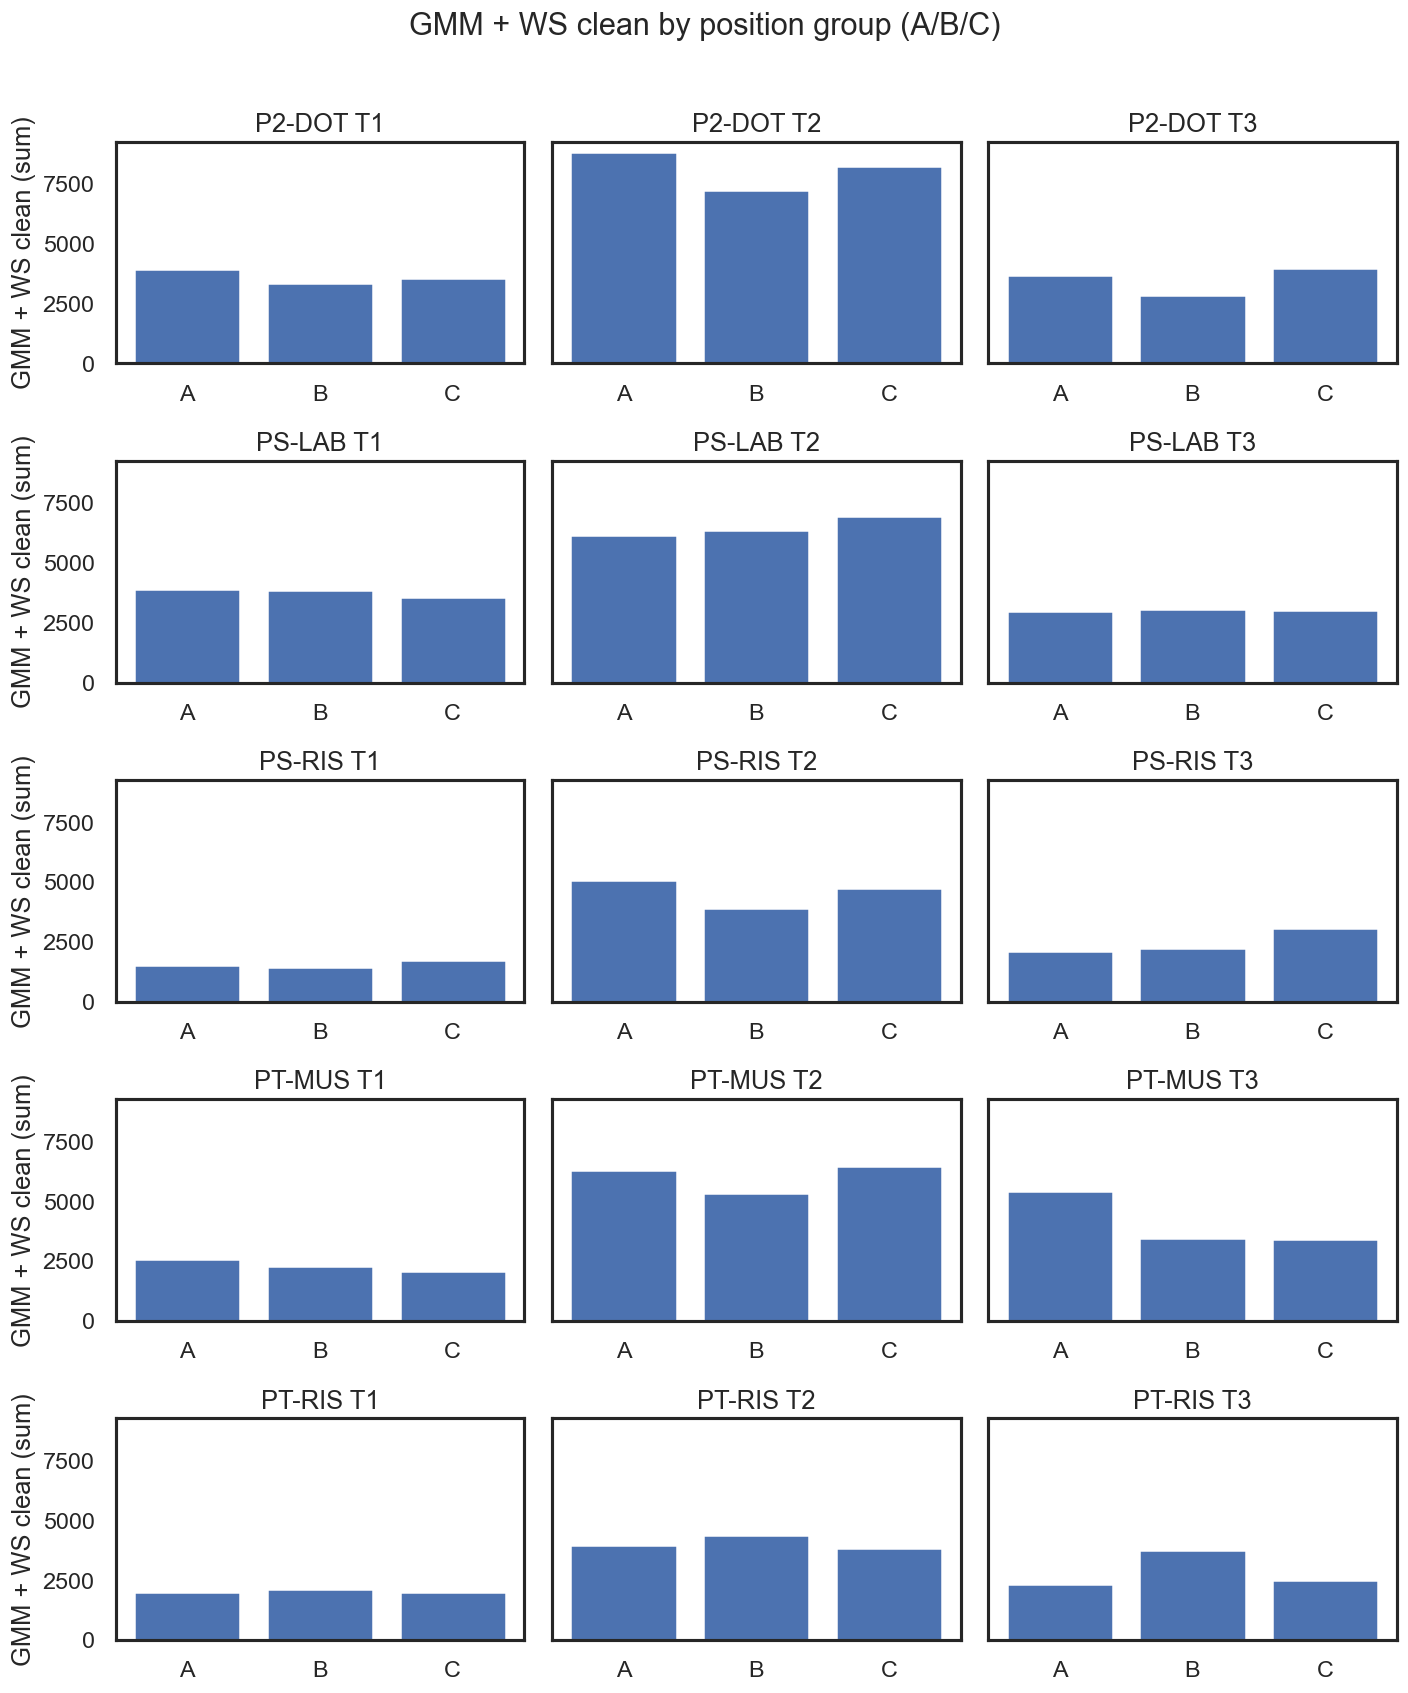

**Figure 28.** Summed GMM+WS clean counts by position group (A/B/C) for each lab×period tile. Saved as `summaries/bar_lab_period_position_group.png`.

In [16]:
# Position A/B/C within each lab-period (GMM clean count)
pos_summary = gmm_summaries["by_lab_period_position"]
labs = sorted(gmm_df["lab"].dropna().unique())
periods = sorted(gmm_df["period"].dropna().unique())
fig, axes = plt.subplots(len(labs), len(periods), figsize=(12, 14), sharey=True)
if len(labs) == 1:
    axes = axes.reshape(1, -1)
for i, lab in enumerate(labs):
    for j, period in enumerate(periods):
        ax = axes[i, j]
        sub = pos_summary[(pos_summary["lab"] == lab) & (pos_summary["period"] == period)]
        sub = sub.sort_values("position_group")
        ax.bar(sub["position_group"], sub["sum_gmm_ws_clean_count"])
        ax.set_title(f"{lab} {period}")
        if j == 0:
            ax.set_ylabel("GMM + WS clean (sum)")
fig.suptitle("GMM + WS clean by position group (A/B/C)", y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "summaries" / "bar_lab_period_position_group.png", dpi=150, bbox_inches="tight")
plt.show()
fig_caption(
    "Summed GMM+WS clean counts by position group (A/B/C) for each lab×period tile.",
    "summaries/bar_lab_period_position_group.png",
)


## Position mosaics — counts per detector slot

Outer grid: **lab × period** (T1–T3). Each tile: **A / B / C** rows × **slots 1–5**.
ImageJ and GMM+WS clean share the same color scale; the third panel shows their per-position difference.

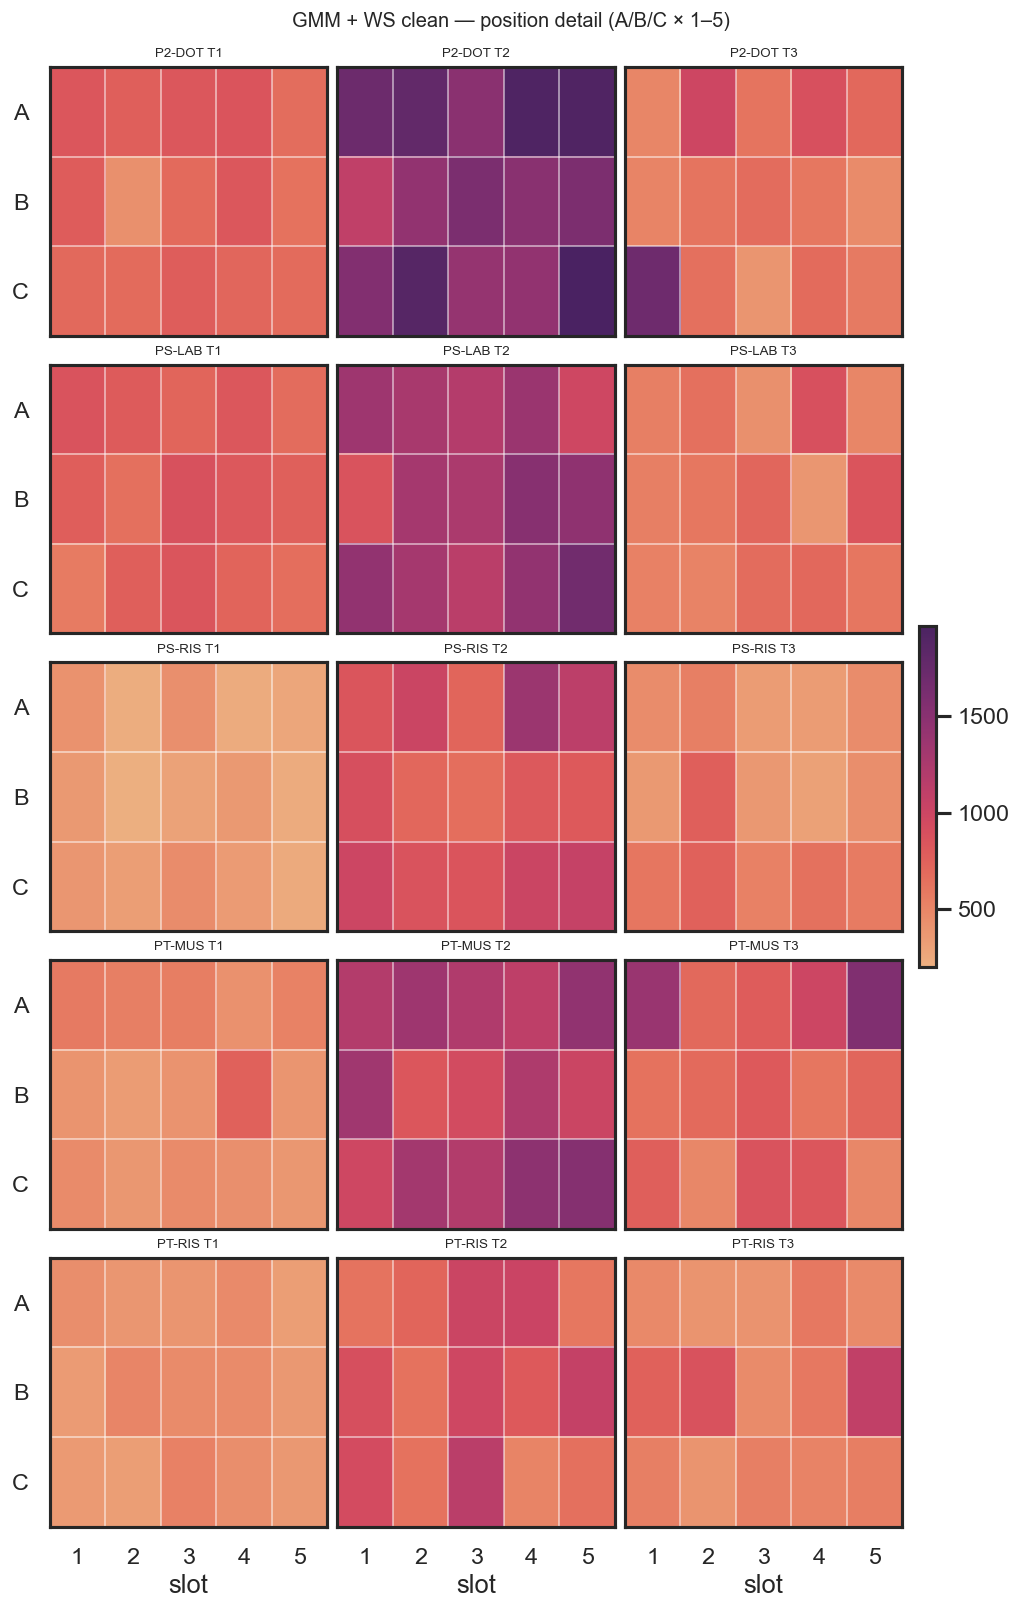

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/position_mosaic_gmm_ws_clean_count.png


**Figure 29.** GMM + WS clean: per-detector-slot counts in a lab×period mosaic (A/B/C rows, slots 1–5 columns); shared color scale with the paired count map. Saved as `summaries/position_mosaic_gmm_ws_clean_count.png`.

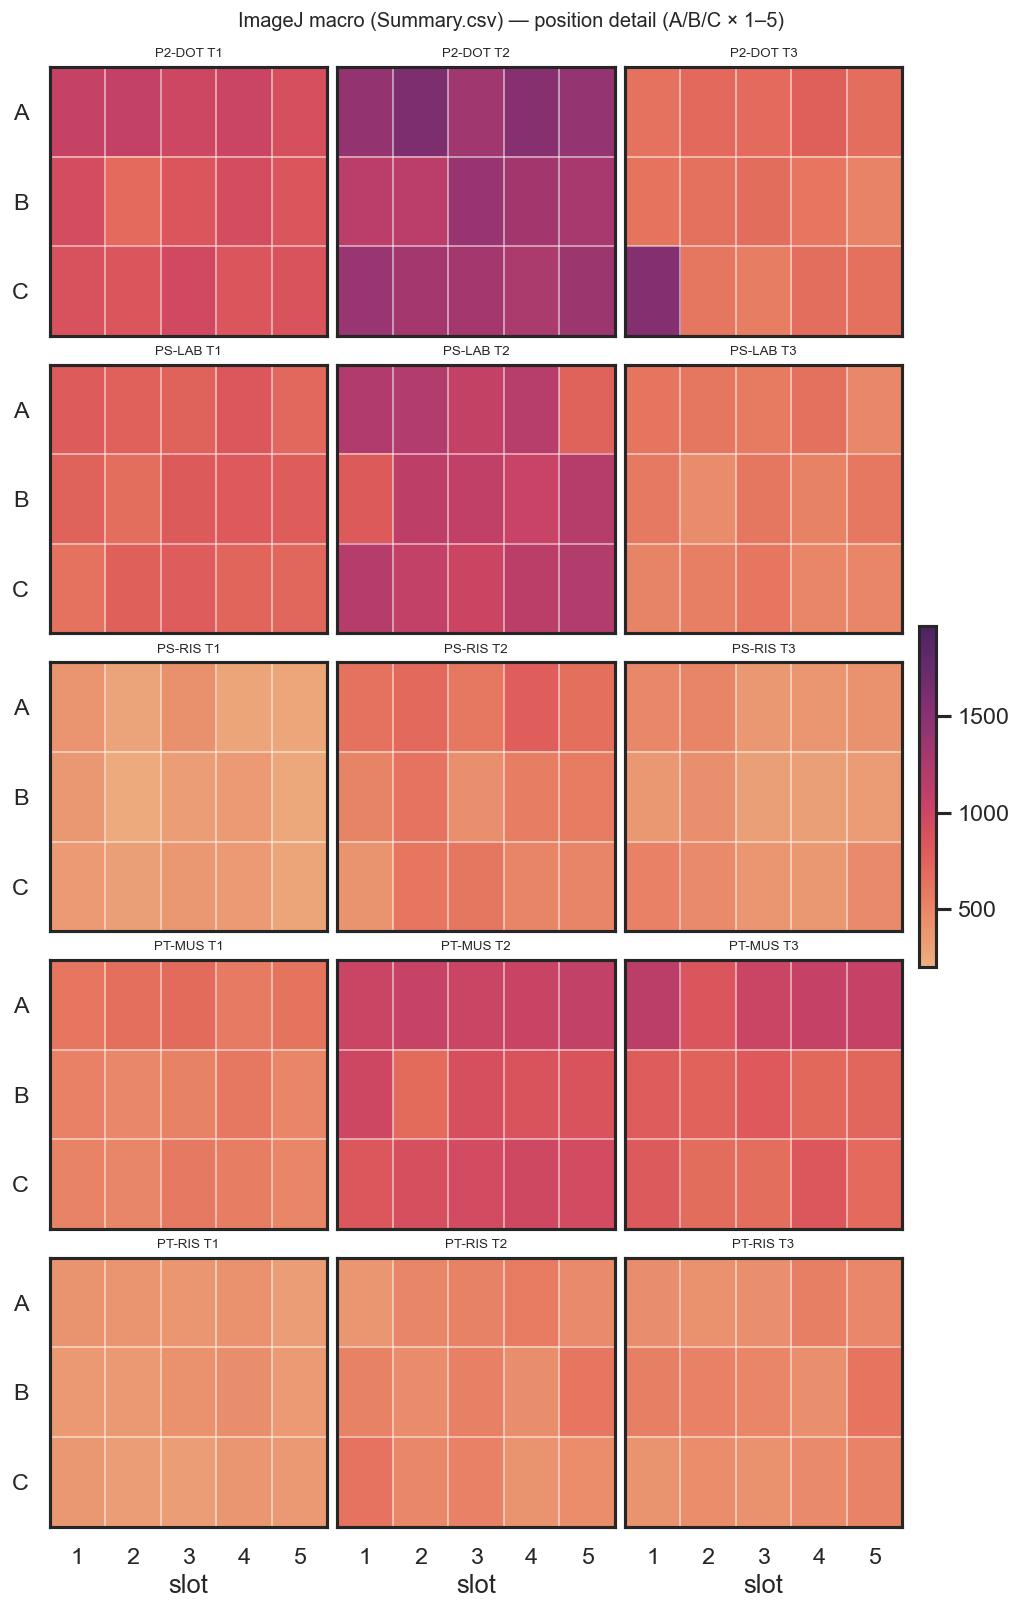

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/position_mosaic_imagej_count.png


**Figure 30.** ImageJ macro (Summary.csv): per-detector-slot counts in a lab×period mosaic (A/B/C rows, slots 1–5 columns); shared color scale with the paired count map. Saved as `summaries/position_mosaic_imagej_count.png`.

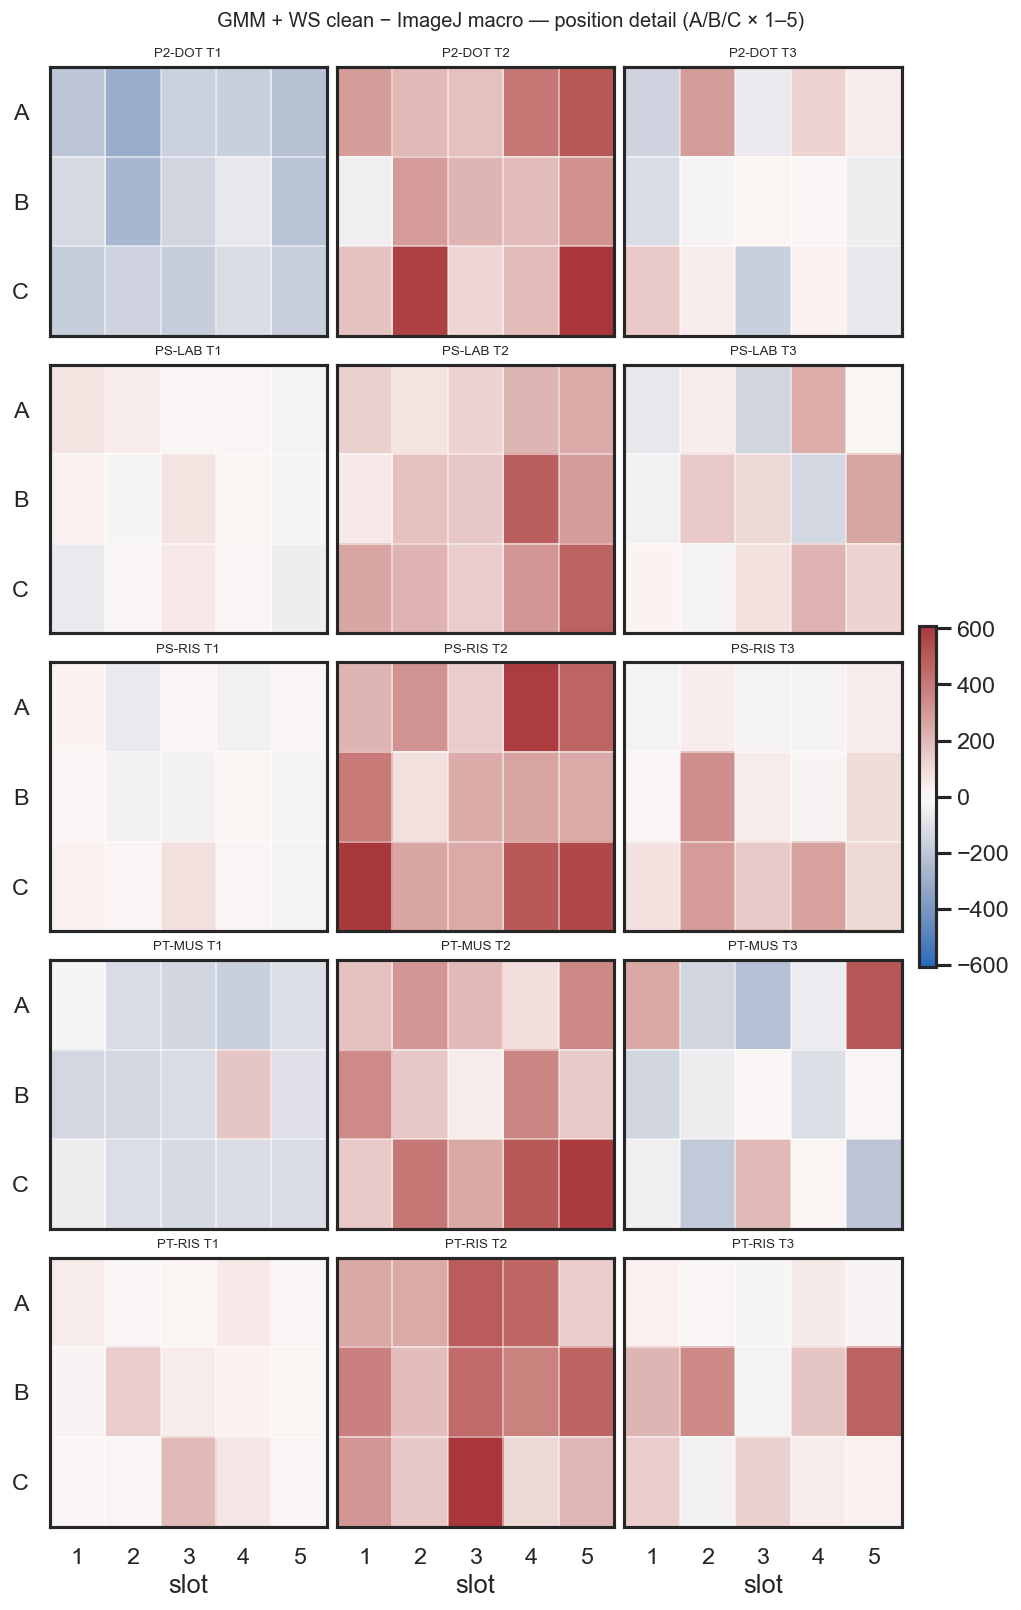

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/cref/outputs/summaries/position_mosaic_gmm_minus_imagej.png


**Figure 31.** Per-slot count difference (GMM+WS clean minus ImageJ macro) on the same mosaic layout; diverging scale centered at zero. Saved as `summaries/position_mosaic_gmm_minus_imagej.png`.

In [17]:
_POSITION_MOSAIC_DIR = OUTPUT_DIR / "summaries"
_POSITION_MOSAIC_DIR.mkdir(parents=True, exist_ok=True)

_position_df = gmm_df[
    ["image", "lab", "period", "position", "position_group", "imagej_count", "gmm_ws_clean_count"]
].copy()
_position_df["gmm_minus_imagej"] = (
    pd.to_numeric(_position_df["gmm_ws_clean_count"], errors="coerce")
    - pd.to_numeric(_position_df["imagej_count"], errors="coerce")
)

_count_scale = pd.concat([
    pd.to_numeric(_position_df["imagej_count"], errors="coerce"),
    pd.to_numeric(_position_df["gmm_ws_clean_count"], errors="coerce"),
])
_count_vmin = float(_count_scale.min())
_count_vmax = float(_count_scale.max())

_count_mosaics = [
    ("gmm_ws_clean_count", "GMM + WS clean", "position_mosaic_gmm_ws_clean_count.png"),
    ("imagej_count", "ImageJ macro (Summary.csv)", "position_mosaic_imagej_count.png"),
]
for col, title, fname in _count_mosaics:
    fig = plot_lab_period_position_heatmaps(
        _position_df,
        col,
        title,
        save_path=_POSITION_MOSAIC_DIR / fname,
        vmin=_count_vmin,
        vmax=_count_vmax,
        cmap="flare",
        inner_grid=True,
    )
    plt.show()
    plt.close(fig)
    print("Saved", _POSITION_MOSAIC_DIR / fname)
    fig_caption(
        f"{title}: per-detector-slot counts in a lab×period mosaic (A/B/C rows, slots 1–5 columns); shared color scale with the paired count map.",
        f"summaries/{fname}",
    )

_diff_abs = float(_position_df["gmm_minus_imagej"].abs().max())
fig = plot_lab_period_position_heatmaps(
    _position_df,
    "gmm_minus_imagej",
    "GMM + WS clean − ImageJ macro",
    save_path=_POSITION_MOSAIC_DIR / "position_mosaic_gmm_minus_imagej.png",
    vmin=-_diff_abs,
    vmax=_diff_abs,
    cmap="vlag",
    inner_grid=True,
)
plt.show()
plt.close(fig)
print("Saved", _POSITION_MOSAIC_DIR / "position_mosaic_gmm_minus_imagej.png")
fig_caption(
    "Per-slot count difference (GMM+WS clean minus ImageJ macro) on the same mosaic layout; diverging scale centered at zero.",
    "summaries/position_mosaic_gmm_minus_imagej.png",
)
